STEP 0 — LOAD DATA
customer_accounts : (3000, 6)
billing_data      : (45596, 5)
monthly_usage     : (3000, 4)
nps_surveys       : (4400, 4)
support_tickets   : (25960, 6)

STEP 1A — FIX FORMAT TANGGAL SUPPORT TICKETS [F1]
NaT tersisa: 778
✅ Format tanggal support_tickets seragam

STEP 1B — CLEANING PER FILE
plan_type unik     : ['enterprise', 'professional', 'starter']
contract_type unik : ['annual', 'monthly']
NPS score=-1 → NaN : 20 baris
✅ Cleaning selesai

STEP 1C — FIX subscription_date [F2]
Customer tanggal dikoreksi: 1428

STEP 1D — TARGET & TENURE
Tenure negatif: 45 customer

STEP 1E — DROP TENURE NEGATIF [F3]
Customer di-drop  : 45
Total customer    : 2955
Churn rate        : 50.49%

STEP 2 — TEMPORAL FILTER [F5]
billing_data    : 45,596 → 44,729 (hapus 867)
nps_surveys     : 4,400 → 4,045 (hapus 355)
support_tickets : 25,960 → 20,509 (hapus 5,451)
✅ Temporal filter selesai

STEP 3 — AGREGASI billing_data
✅ billing_agg: (3000, 13)

STEP 4 — AGREGASI nps_surveys
✅ nps_agg: (273

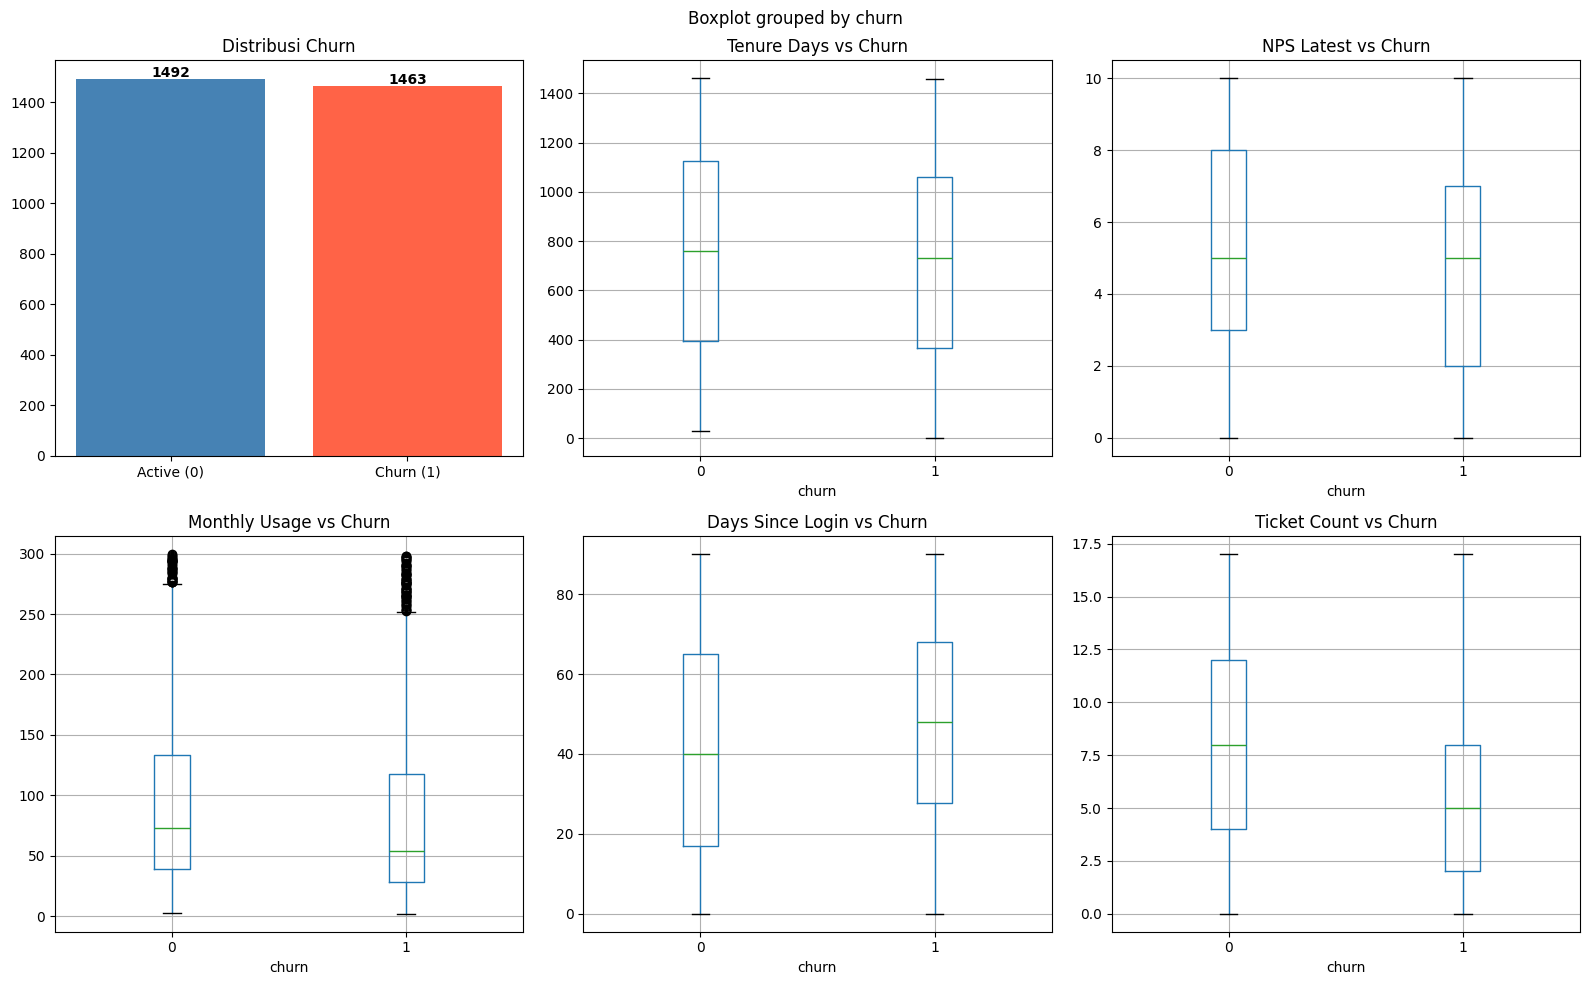

✅ Saved: eda_overview_fixed.png

STEP 11 — SEGMEN & KORELASI


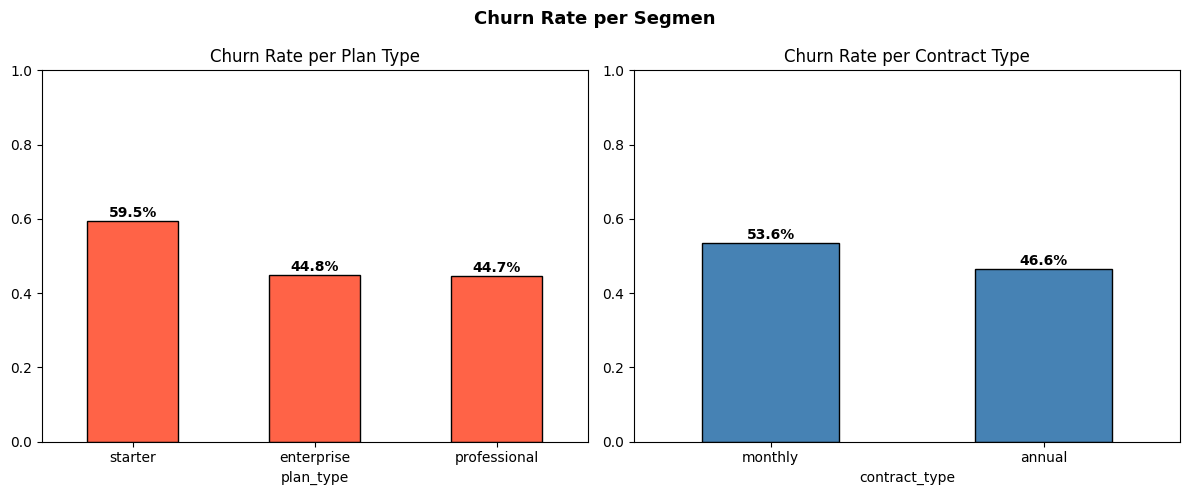


Top 15 korelasi:
days_since_survey         0.326877
ticket_count             -0.285019
days_since_last_ticket    0.268297
resolved_tickets         -0.267408
technical_tickets        -0.231050
billing_tickets          -0.214422
open_tickets             -0.203952
high_tickets             -0.202584
has_nps                  -0.174281
nps_count                -0.161099
critical_tickets         -0.146870
feature_req_tickets      -0.126461
days_since_login          0.100391
avg_payment_value        -0.099291
monthly_usage_hrs        -0.091303
✅ Saved: eda_segmen_fixed.png

STEP 12 — FEATURE ENGINEERING v2
✅ FE selesai — Shape: (2955, 50) | Missing: 0

STEP 13 — ENCODING & SPLIT
  plan_type: {'enterprise': np.int64(0), 'professional': np.int64(1), 'starter': np.int64(2)}
  contract_type: {'annual': np.int64(0), 'monthly': np.int64(1)}

Train: (2364, 49) | Churn rate: 50.51%
Test : (591, 49)  | Churn rate: 50.42%
Jumlah fitur: 49

STEP 14 — RANDOM FOREST TUNED (Baseline)
Fitting 5 folds for ea

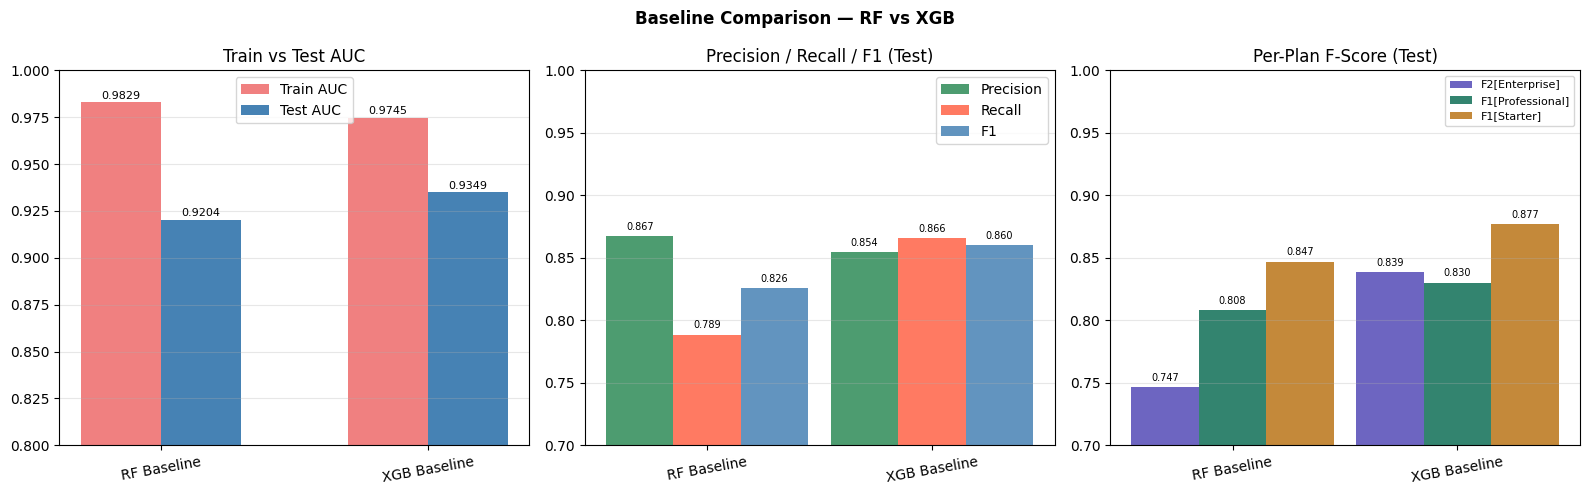

✅ Saved: baseline_comparison.png

STEP 17 — FEATURE IMPORTANCE (RF + XGB)

Top 15 — Random Forest:
                feature  importance   category
 days_since_last_ticket    0.289309   original
days_since_last_payment    0.124447   original
      days_since_survey    0.082356   original
       days_since_login    0.057143   original
    login_recency_ratio    0.035770 engineered
           ticket_count    0.035268   original
       engagement_score    0.024118 engineered
       resolved_tickets    0.023012   original
          payment_count    0.019446   original
      avg_payment_value    0.018126   original
  nps_usage_interaction    0.015105 engineered
      monthly_usage_hrs    0.014744   original
          contract_type    0.014313   original
      support_intensity    0.014151 engineered
            tenure_days    0.013490   original

Top 15 — XGBoost:
                feature  importance   category
          contract_type    0.096949   original
 days_since_last_ticket    0.094917 

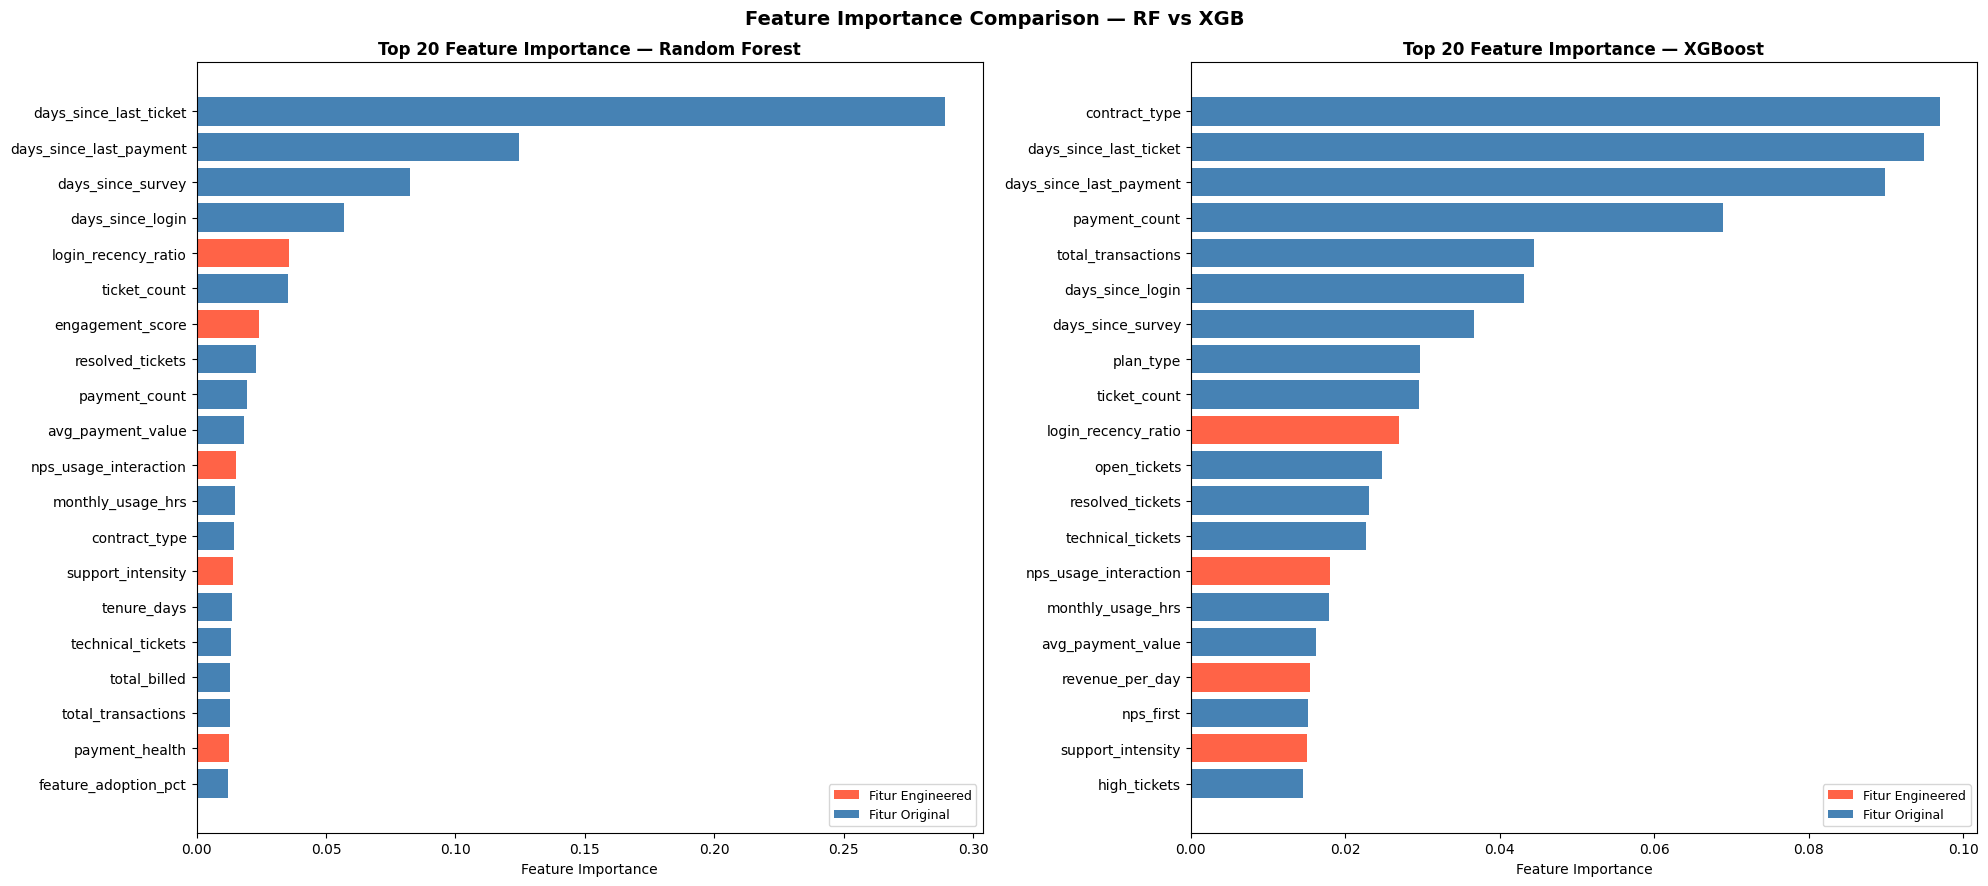

✅ Saved: feature_importance_comparison.png

STEP 18 — RF: CLASS WEIGHT TUNING + THRESHOLD OPTIMIZATION
Konsep: class_weight menyesuaikan loss function RF agar lebih
sensitif pada kelas churn. Digabung threshold optimal recall≥0.90.
Pemilihan config: composite score tertinggi dengan recall≥0.90.

Config            CV AUC   TeAUC    Prec  Recall      F1  Thresh90  Rec@90  Composite@90
--------------------------------------------------------------------------------------------
balanced          0.9263  0.9198  0.8667  0.7852  0.8239     0.361  0.9027        0.8527 ✅
churn 1.5x        0.9288  0.9201  0.8367  0.8423  0.8395     0.441  0.9027        0.8626 ✅
churn 2x          0.9291  0.9212  0.8142  0.8826  0.8470     0.473  0.9027        0.8628 ✅
churn 2.5x        0.9287  0.9224  0.7976  0.8993  0.8454     0.494  0.9027        0.8649 ✅
churn 3x          0.9294  0.9226  0.7832  0.9094  0.8416     0.518  0.9027        0.8663 ✅

✅ Config terpilih: churn 3x
   Alasan: recall≥0.90 terpenuhi + co

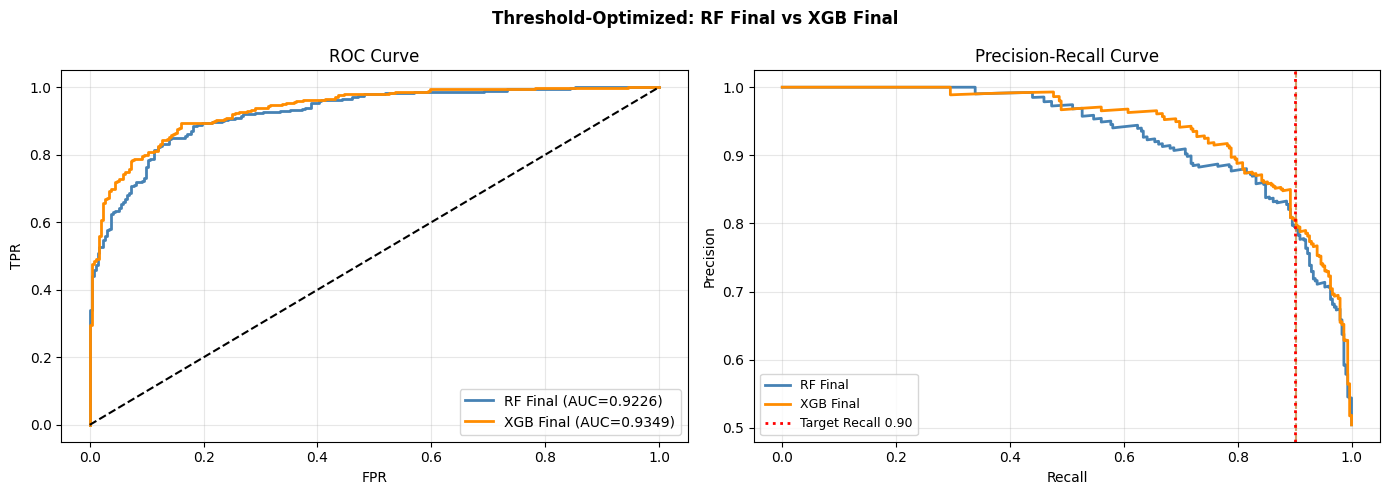

✅ Saved: threshold_comparison.png

STEP 21 — WOA: COMPOSITE MULTI-METRIC RF OPTIMIZATION
Fitness: Score = 0.40×F2[Ent] + 0.28×AUC + 0.20×F1[Pro] + 0.12×F1[Sta]
class_weight: {0:1, 1:2} — konsisten dengan Strategi B terbaik

plan_type column index: 0

Konfigurasi WOA:
  Fitness    : Composite Multi-Metric (bukan single AUC)
  Weights    : F2_Ent=0.40, AUC=0.28, F1_Pro=0.20, F1_Sta=0.12
  class_weight: {0: 1, 1: 2}
  n_whales   : 20
  max_iter   : 30
  cv         : 5-fold stratified
  Estimasi   : ~2–3 jam (tergantung hardware)

Init 20 paus | class_weight={0: 1, 1: 2}
Composite awal terbaik: 0.8820
 Iter  Best Composite   Curr Best    Elapsed
----------------------------------------------
    1          0.8820      0.8820     490.9s
    2          0.8820      0.8820     781.5s
    3          0.8820      0.8804    1093.8s
    4          0.8820      0.8814    1309.5s
    5          0.8820      0.8820    1541.0s
    6          0.8826      0.8826    1875.7s
    7          0.8826      0.8826

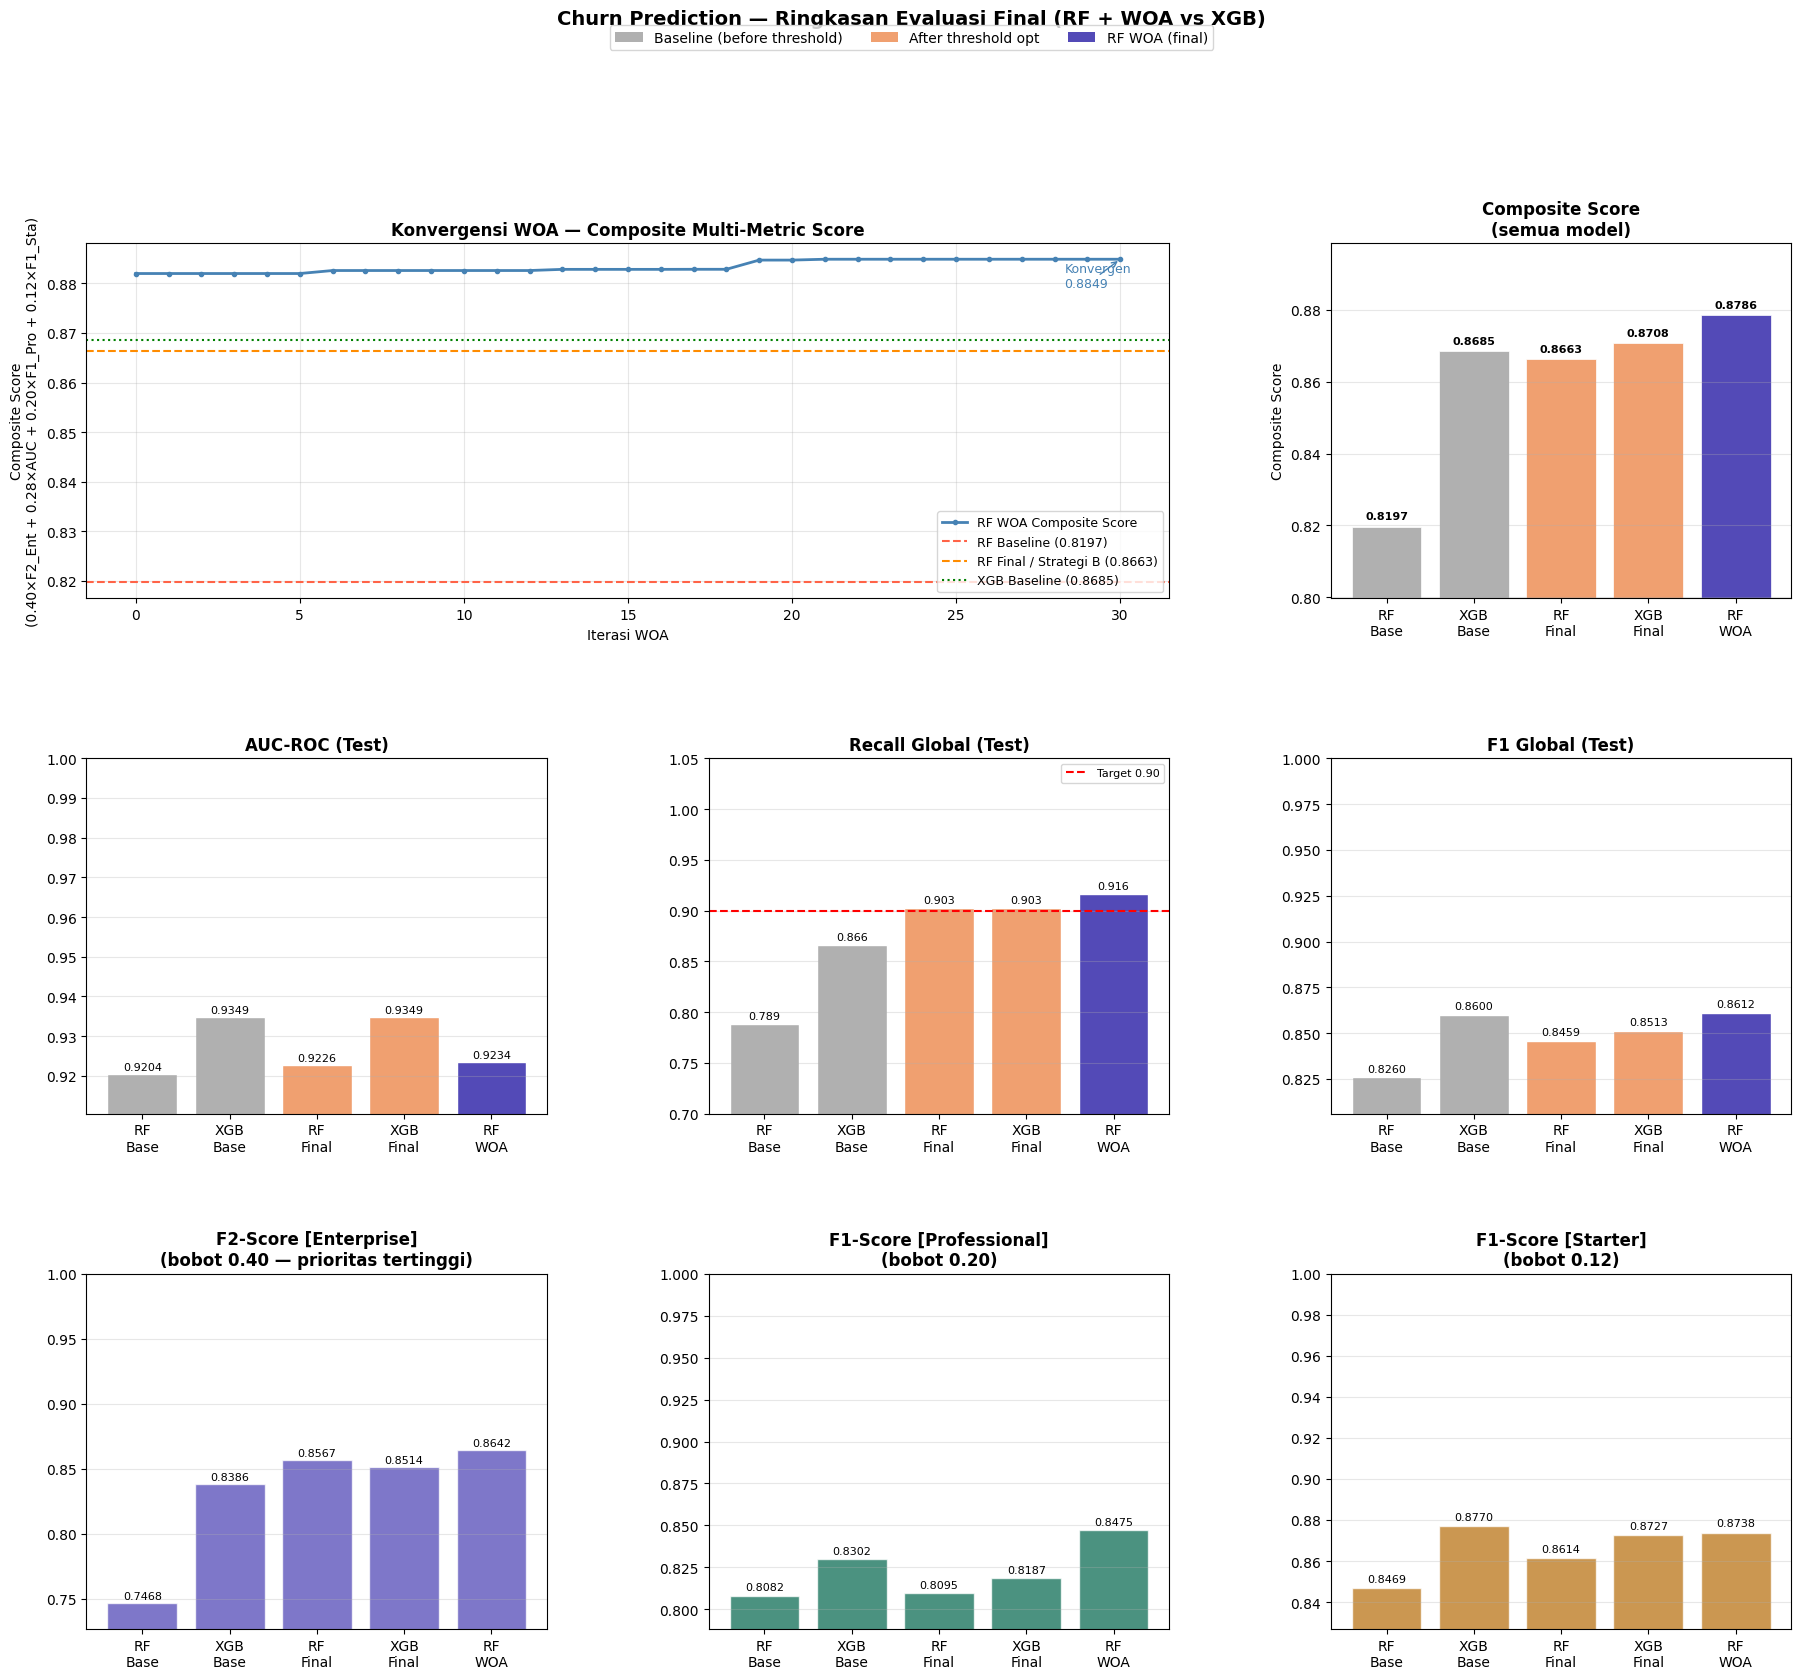

✅ Saved: final_comprehensive_comparison.png


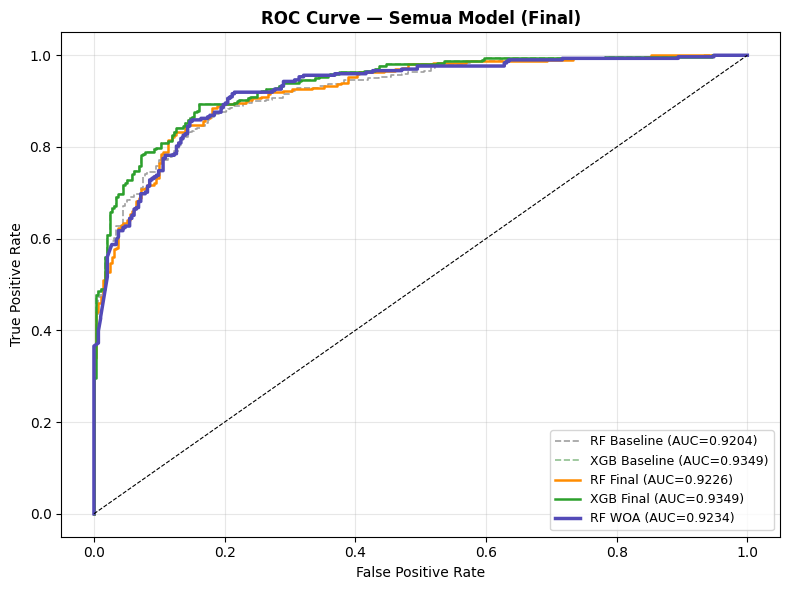

✅ Saved: roc_curve_final.png


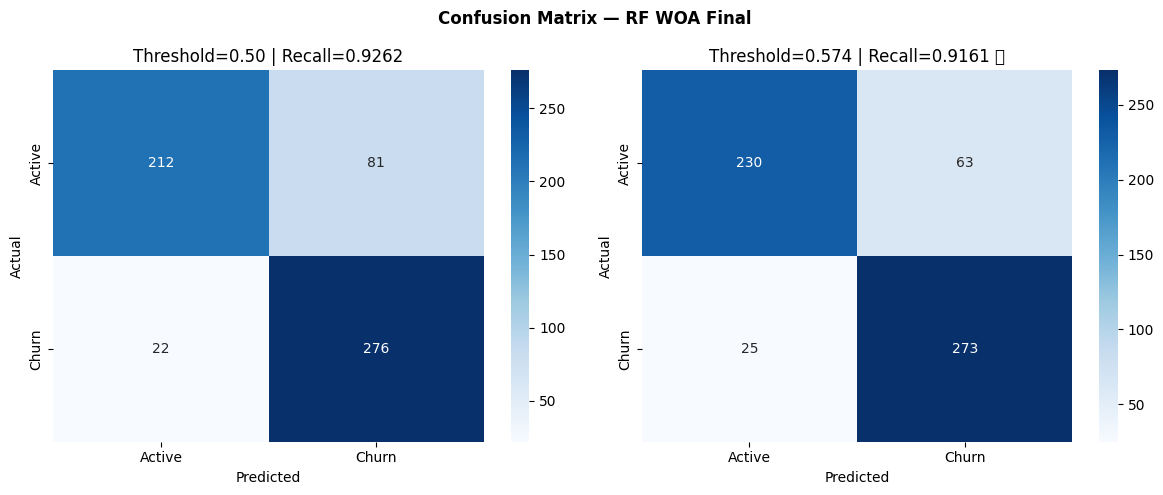

✅ Saved: confusion_matrix_woa.png

PIPELINE v3.0 SELESAI

Model final terpilih : RF WOA + threshold=0.574
Composite Score      : 0.8786
WOA Best Composite   : 0.8849
Test AUC             : 0.9234
Recall (global)      : 0.9161
Precision (global)   : 0.8125
F1 (global)          : 0.8612

── Per-Plan Final ──
F2 [Enterprise]  : 0.8642  | Recall: 0.8750
F1 [Professional]: 0.8475  | Recall: 0.9375
F1 [Starter]     : 0.8738  | Recall: 0.9221

WOA Params       : {'n_estimators': 491, 'max_depth': 4, 'min_samples_split': 12, 'min_samples_leaf': 10, 'max_features': 0.865}

Output files:
  - eda_overview_fixed.png
  - eda_segmen_fixed.png
  - merged_dataset.csv
  - baseline_comparison.png
  - feature_importance_comparison.png
  - threshold_comparison.png
  - final_comprehensive_comparison.png
  - roc_curve_final.png
  - confusion_matrix_woa.png


In [ ]:
"""
=============================================================
CUSTOMER CHURN ANALYSIS — PIPELINE v3.0
Multi-Metric WOA + Plan-Type Stratified Evaluation
=============================================================
Perubahan dari v2.0:
  [V1] Hapus LightGBM — fokus RF dan XGBoost sebagai benchmark
  [V2] evaluate_model v2 — menampilkan metrik per plan_type
       - F2-Score [Enterprise]   (β=2, prioritas recall)
       - F1-Score [Professional] (balanced)
       - F1-Score [Starter]      (balanced)
       - AUC-ROC  [Global]
       - Composite = 0.40×F2[Ent] + 0.28×AUC + 0.20×F1[Pro] + 0.12×F1[Sta]
  [V3] Threshold optimization untuk KEDUA model (RF + XGB)
       - RF : class_weight {0:1, 1:2} + threshold recall ≥ 0.90
       - XGB: threshold optimization recall ≥ 0.90
  [V4] WOA fitness menggunakan Composite Multi-Metric
       (bukan single AUC-ROC — fix masalah "nilai kacau" single metric)
  [V5] class_weight WOA: {0:1, 1:2} (konsisten dengan Strategi B terbaik)
  [V6] Visualisasi WOA: convergence + before/after + per-plan breakdown
  [V7] Fix NameError prec_a (hapus referensi Strategi A yang tidak ada)
  [V8] reset_index setelah train_test_split untuk indexing bersih
=============================================================
Justifikasi bobot composite (berbasis revenue at risk aktual):
  Enterprise  : Rp 28.16jt at risk = 76.3% → bobot 0.40 (F2, β=2)
  AUC-ROC     : anchor statistik global    → bobot 0.28
  Professional: Rp  6.32jt at risk = 17.1% → bobot 0.20 (F1)
  Starter     : Rp  2.40jt at risk =  6.5% → bobot 0.12 (F1)
=============================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import time

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     RandomizedSearchCV, StratifiedKFold)
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, precision_recall_curve,
                             precision_score, recall_score, f1_score,
                             fbeta_score, accuracy_score, roc_curve)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')


# ─────────────────────────────────────────────────────────
# STEP 0 — LOAD DATA
# ─────────────────────────────────────────────────────────
print("=" * 60)
print("STEP 0 — LOAD DATA")
print("=" * 60)

ca  = pd.read_csv('customer_accounts.csv')
bd  = pd.read_csv('billing_data.csv')
mu  = pd.read_csv('monthly_usage_metrics.csv')
nps = pd.read_csv('nps_surveys.csv')
st  = pd.read_csv('support_tickets.csv')

REF_DATE = pd.Timestamp('2024-12-31')

print(f"customer_accounts : {ca.shape}")
print(f"billing_data      : {bd.shape}")
print(f"monthly_usage     : {mu.shape}")
print(f"nps_surveys       : {nps.shape}")
print(f"support_tickets   : {st.shape}")


# ─────────────────────────────────────────────────────────
# STEP 1A — FIX FORMAT TANGGAL SUPPORT TICKETS [F1]
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 1A — FIX FORMAT TANGGAL SUPPORT TICKETS [F1]")
print("=" * 60)

st_raw = st.copy()
st['created_date'] = pd.to_datetime(st['created_date'], dayfirst=True, errors='coerce')

nat_mask = st['created_date'].isna()
if nat_mask.sum() > 0:
    st.loc[nat_mask, 'created_date'] = pd.to_datetime(
        st_raw.loc[nat_mask, 'created_date'], format='%d-%b-%y', errors='coerce'
    )
nat_mask2 = st['created_date'].isna()
if nat_mask2.sum() > 0:
    st.loc[nat_mask2, 'created_date'] = pd.to_datetime(
        st_raw.loc[nat_mask2, 'created_date'], format='%d-%b-%Y', errors='coerce'
    )

print(f"NaT tersisa: {st['created_date'].isna().sum()}")
print("✅ Format tanggal support_tickets seragam")


# ─────────────────────────────────────────────────────────
# STEP 1B — CLEANING PER FILE
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 1B — CLEANING PER FILE")
print("=" * 60)

ca['subscription_date'] = pd.to_datetime(ca['subscription_date'], dayfirst=True, errors='coerce')
ca['unsubscribed_date'] = pd.to_datetime(ca['unsubscribed_date'], dayfirst=True, errors='coerce')
ca['plan_type']         = ca['plan_type'].str.strip().str.lower()
ca['contract_type']     = ca['contract_type'].str.strip().str.lower()

bd['billing_date'] = pd.to_datetime(bd['billing_date'], dayfirst=True, errors='coerce')
bd['payment_date'] = pd.to_datetime(bd['payment_date'], dayfirst=True, errors='coerce')
bd['record_type']  = bd['record_type'].str.strip().str.lower()

mu['last_login_date'] = pd.to_datetime(mu['last_login_date'], dayfirst=True, errors='coerce')
nps['survey_date']    = pd.to_datetime(nps['survey_date'], dayfirst=True, errors='coerce')

n_invalid_nps      = (nps['nps_score'] == -1).sum()
nps['nps_score']   = nps['nps_score'].replace(-1, np.nan)

print(f"plan_type unik     : {sorted(ca['plan_type'].unique())}")
print(f"contract_type unik : {sorted(ca['contract_type'].unique())}")
print(f"NPS score=-1 → NaN : {n_invalid_nps} baris")
print("✅ Cleaning selesai")


# ─────────────────────────────────────────────────────────
# STEP 1C — FIX subscription_date → first_billing_date [F2]
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 1C — FIX subscription_date [F2]")
print("=" * 60)

first_billing = (
    bd.groupby('customer_id')['billing_date']
    .min().reset_index()
    .rename(columns={'billing_date': 'first_billing_date'})
)
ca = ca.merge(first_billing, on='customer_id', how='left')
ca['date_corrected'] = (ca['first_billing_date'] < ca['subscription_date']).astype(int)
ca['effective_start'] = ca['first_billing_date']

print(f"Customer tanggal dikoreksi: {ca['date_corrected'].sum()}")


# ─────────────────────────────────────────────────────────
# STEP 1D — TARGET VARIABLE & TENURE
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 1D — TARGET & TENURE")
print("=" * 60)

ca['churn']       = ca['unsubscribed_date'].notna().astype(int)
ca['tenure_days'] = (ca['unsubscribed_date'].fillna(REF_DATE) - ca['effective_start']).dt.days
neg_tenure        = ca[ca['tenure_days'] < 0]
print(f"Tenure negatif: {len(neg_tenure)} customer")


# ─────────────────────────────────────────────────────────
# STEP 1E — DROP TENURE NEGATIF [F3]
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 1E — DROP TENURE NEGATIF [F3]")
print("=" * 60)

invalid_customers = ca[ca['tenure_days'] < 0]['customer_id'].tolist()
ca = ca[ca['tenure_days'] >= 0].copy()
print(f"Customer di-drop  : {len(invalid_customers)}")
print(f"Total customer    : {len(ca)}")
print(f"Churn rate        : {ca['churn'].mean():.2%}")


# ─────────────────────────────────────────────────────────
# STEP 2 — TEMPORAL FILTER [F5]
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 2 — TEMPORAL FILTER [F5]")
print("=" * 60)

cutoff = ca[['customer_id', 'unsubscribed_date', 'churn']].copy()

bd_merged  = bd.merge(cutoff, on='customer_id', how='left')
bd_clean   = bd_merged[~((bd_merged['churn'] == 1) & (bd_merged['billing_date'] > bd_merged['unsubscribed_date']))].copy()

nps_merged = nps.merge(cutoff, on='customer_id', how='left')
nps_clean  = nps_merged[~((nps_merged['churn'] == 1) & (nps_merged['survey_date'] > nps_merged['unsubscribed_date']))].copy()

st_merged  = st.merge(cutoff, on='customer_id', how='left')
st_clean   = st_merged[~((st_merged['churn'] == 1) & (st_merged['created_date'] > st_merged['unsubscribed_date']))].copy()

print(f"billing_data    : {len(bd_merged):,} → {len(bd_clean):,} (hapus {len(bd_merged)-len(bd_clean):,})")
print(f"nps_surveys     : {len(nps_merged):,} → {len(nps_clean):,} (hapus {len(nps_merged)-len(nps_clean):,})")
print(f"support_tickets : {len(st_merged):,} → {len(st_clean):,} (hapus {len(st_merged)-len(st_clean):,})")
print("✅ Temporal filter selesai")


# ─────────────────────────────────────────────────────────
# STEP 3 — AGREGASI billing_data
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 3 — AGREGASI billing_data")
print("=" * 60)

payment_only = bd_clean[bd_clean['record_type'] == 'payment'].copy()
payment_only['days_late'] = (payment_only['payment_date'] - payment_only['billing_date']).dt.days

billing_agg_base = bd_clean.groupby('customer_id').agg(
    total_billed        = ('payment_value', 'sum'),
    avg_payment_value   = ('payment_value', 'mean'),
    total_transactions  = ('record_type', 'count'),
    dunning_count       = ('record_type', lambda x: (x == 'dunning').sum()),
    payment_count       = ('record_type', lambda x: (x == 'payment').sum()),
    last_billing_date   = ('billing_date', 'max'),
).reset_index()

billing_agg_pay = payment_only.groupby('customer_id').agg(
    avg_days_late      = ('days_late', 'mean'),
    max_days_late      = ('days_late', 'max'),
    late_payment_count = ('days_late', lambda x: (x > 0).sum()),
    last_payment_date  = ('payment_date', 'max'),
).reset_index()

billing_agg = billing_agg_base.merge(billing_agg_pay, on='customer_id', how='left')
billing_agg['dunning_ratio']           = billing_agg['dunning_count'] / billing_agg['total_transactions']
billing_agg['days_since_last_payment'] = (REF_DATE - billing_agg['last_payment_date']).dt.days
print(f"✅ billing_agg: {billing_agg.shape}")


# ─────────────────────────────────────────────────────────
# STEP 4 — AGREGASI nps_surveys
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 4 — AGREGASI nps_surveys")
print("=" * 60)

nps_sorted = nps_clean.sort_values(['customer_id', 'survey_date'])
nps_agg = nps_sorted.groupby('customer_id').agg(
    nps_latest       = ('nps_score', 'last'),
    nps_first        = ('nps_score', 'first'),
    nps_avg          = ('nps_score', 'mean'),
    nps_min          = ('nps_score', 'min'),
    nps_count        = ('nps_score', 'count'),
    last_survey_date = ('survey_date', 'max'),
).reset_index()
nps_agg['nps_trend']         = nps_agg['nps_latest'] - nps_agg['nps_first']
nps_agg['days_since_survey'] = (REF_DATE - nps_agg['last_survey_date']).dt.days
print(f"✅ nps_agg: {nps_agg.shape}")


# ─────────────────────────────────────────────────────────
# STEP 5 — AGREGASI support_tickets
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 5 — AGREGASI support_tickets")
print("=" * 60)

tickets_agg = st_clean.groupby('customer_id').agg(
    ticket_count        = ('ticket_id', 'count'),
    critical_tickets    = ('priority', lambda x: (x == 'Critical').sum()),
    high_tickets        = ('priority', lambda x: (x == 'High').sum()),
    billing_tickets     = ('category', lambda x: (x == 'Billing').sum()),
    technical_tickets   = ('category', lambda x: (x == 'Technical').sum()),
    feature_req_tickets = ('category', lambda x: (x == 'Feature Request').sum()),
    open_tickets        = ('status',   lambda x: x.isin(['Open', 'In Progress']).sum()),
    resolved_tickets    = ('status',   lambda x: x.isin(['Resolved', 'Closed']).sum()),
    last_ticket_date    = ('created_date', 'max'),
).reset_index()

tickets_agg['open_ticket_ratio']      = tickets_agg['open_tickets'] / tickets_agg['ticket_count']
tickets_agg['critical_ticket_ratio']  = tickets_agg['critical_tickets'] / tickets_agg['ticket_count']
tickets_agg['days_since_last_ticket'] = (REF_DATE - tickets_agg['last_ticket_date']).dt.days
print(f"✅ tickets_agg: {tickets_agg.shape}")


# ─────────────────────────────────────────────────────────
# STEP 6 — BASE TABLE & MONTHLY USAGE
# ─────────────────────────────────────────────────────────
mu['days_since_login'] = (REF_DATE - mu['last_login_date']).dt.days


# ─────────────────────────────────────────────────────────
# STEP 7 — FINAL MERGE
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 7 — FINAL MERGE")
print("=" * 60)

df = ca.copy()
df = df.merge(mu[['customer_id', 'monthly_usage_hrs', 'feature_adoption_pct', 'days_since_login']], on='customer_id', how='left')
df = df.merge(billing_agg,  on='customer_id', how='left')
df = df.merge(nps_agg,      on='customer_id', how='left')
df = df.merge(tickets_agg,  on='customer_id', how='left')

ticket_zero_cols = ['ticket_count', 'critical_tickets', 'high_tickets', 'billing_tickets',
                    'technical_tickets', 'feature_req_tickets', 'open_tickets', 'resolved_tickets',
                    'open_ticket_ratio', 'critical_ticket_ratio']
df[ticket_zero_cols] = df[ticket_zero_cols].fillna(0)
df['days_since_last_ticket'] = df['days_since_last_ticket'].fillna(df['days_since_last_ticket'].max() + 30)
df['has_nps']   = df['nps_latest'].notna().astype(int)
df['nps_first'] = df['nps_first'].fillna(df['nps_latest'])
df['nps_count'] = df['nps_count'].fillna(0)
df['nps_trend'] = (df['nps_latest'] - df['nps_first']).fillna(0)
df['days_since_survey'] = df['days_since_survey'].fillna(df['days_since_survey'].max() + 30)
for col in ['nps_latest', 'nps_avg', 'nps_min', 'nps_first']:
    df[col] = df[col].fillna(df[col].median())

df.to_csv('merged_dataset.csv', index=False)
print(f"✅ Final merged: {df.shape} | Churn rate: {df['churn'].mean():.2%}")
print(f"Missing total : {df.isnull().sum().sum()}")


# ─────────────────────────────────────────────────────────
# STEP 8 — DROP KOLOM LEAKAGE
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 8 — DROP KOLOM LEAKAGE")
print("=" * 60)

drop_cols = [
    'customer_id', 'unsubscribed_date', 'subscription_date',
    'effective_start', 'first_billing_date', 'last_billing_date',
    'last_payment_date', 'last_survey_date', 'last_ticket_date', 'last_login_date',
]
df_model = df.drop(columns=drop_cols, errors='ignore')
print(f"✅ Shape siap modeling: {df_model.shape}")


# ─────────────────────────────────────────────────────────
# STEP 9 — HEALTH CHECK
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 9 — HEALTH CHECK")
print("=" * 60)
print(f"Churn rate   : {df_model['churn'].mean():.2%}")
print(f"Missing total: {df_model.isnull().sum().sum()}")
print(f"Inf total    : {np.isinf(df_model.select_dtypes(include=np.number)).sum().sum()}")
print(f"plan_type    : {sorted(df_model['plan_type'].unique())}")


# ─────────────────────────────────────────────────────────
# STEP 10 — EDA VISUAL
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 10 — EDA VISUAL")
print("=" * 60)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EDA — Distribusi Fitur vs Churn', fontsize=14, fontweight='bold')

churn_counts = df_model['churn'].value_counts()
axes[0,0].bar(['Active (0)', 'Churn (1)'], churn_counts.values, color=['steelblue', 'tomato'])
axes[0,0].set_title('Distribusi Churn')
for i, v in enumerate(churn_counts.values):
    axes[0,0].text(i, v + 10, str(v), ha='center', fontweight='bold')

df_model.boxplot(column='tenure_days',      by='churn', ax=axes[0,1]); axes[0,1].set_title('Tenure Days vs Churn')
df_model.boxplot(column='nps_latest',       by='churn', ax=axes[0,2]); axes[0,2].set_title('NPS Latest vs Churn')
df_model.boxplot(column='monthly_usage_hrs', by='churn', ax=axes[1,0]); axes[1,0].set_title('Monthly Usage vs Churn')
df_model.boxplot(column='days_since_login', by='churn', ax=axes[1,1]); axes[1,1].set_title('Days Since Login vs Churn')
df_model.boxplot(column='ticket_count',     by='churn', ax=axes[1,2]); axes[1,2].set_title('Ticket Count vs Churn')

plt.tight_layout()
plt.savefig('eda_overview_fixed.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_overview_fixed.png")


# ─────────────────────────────────────────────────────────
# STEP 11 — SEGMEN & KORELASI
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 11 — SEGMEN & KORELASI")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Churn Rate per Segmen', fontsize=13, fontweight='bold')

plan_churn = df_model.groupby('plan_type')['churn'].mean().sort_values(ascending=False)
plan_churn.plot(kind='bar', ax=axes[0], color='tomato', edgecolor='black')
axes[0].set_title('Churn Rate per Plan Type'); axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(plan_churn.values):
    axes[0].text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

contract_churn = df_model.groupby('contract_type')['churn'].mean().sort_values(ascending=False)
contract_churn.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Churn Rate per Contract Type'); axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(contract_churn.values):
    axes[1].text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_segmen_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

num_cols   = df_model.select_dtypes(include=np.number).columns.tolist()
corr       = df_model[num_cols].corr()['churn'].drop('churn')
corr_sorted = corr.reindex(corr.abs().sort_values(ascending=False).index)
print(f"\nTop 15 korelasi:\n{corr_sorted.head(15).to_string()}")
print("✅ Saved: eda_segmen_fixed.png")


# ─────────────────────────────────────────────────────────
# STEP 12 — FEATURE ENGINEERING v2
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 12 — FEATURE ENGINEERING v2")
print("=" * 60)

df_fe = df_model.copy()

df_fe['engagement_score']      = (df_fe['monthly_usage_hrs'] * df_fe['feature_adoption_pct'] / (df_fe['days_since_login'] + 1)).clip(upper=1e6)
df_fe['usage_per_tenure']      = df_fe['monthly_usage_hrs'] / (df_fe['tenure_days'] / 30 + 1)
df_fe['payment_health']        = (df_fe['avg_payment_value'] / (df_fe['dunning_count'] + 1) / (df_fe['avg_days_late'].fillna(0) + 1)).clip(upper=1e6)
df_fe['ever_dunning']          = (df_fe['dunning_count'] > 0).astype(int)
df_fe['late_payment_rate']     = df_fe['late_payment_count'] / (df_fe['payment_count'] + 1)
df_fe['support_intensity']     = df_fe['ticket_count'] / (df_fe['tenure_days'] / 30 + 1)
df_fe['has_open_critical']     = ((df_fe['critical_tickets'] > 0) & (df_fe['open_ticket_ratio'] > 0)).astype(int)
df_fe['unresolved_rate']       = df_fe['open_tickets'] / (df_fe['ticket_count'] + 1)
df_fe['nps_usage_interaction'] = df_fe['nps_latest'] * df_fe['monthly_usage_hrs']
df_fe['nps_tenure_interaction']= df_fe['nps_latest'] * df_fe['tenure_days']
df_fe['login_recency_ratio']   = df_fe['days_since_login'] / (df_fe['tenure_days'] + 1)
df_fe['revenue_per_day']       = df_fe['total_billed'] / (df_fe['tenure_days'] + 1)

fe_cols = [
    'engagement_score', 'usage_per_tenure', 'payment_health', 'ever_dunning',
    'late_payment_rate', 'support_intensity', 'has_open_critical', 'unresolved_rate',
    'nps_usage_interaction', 'nps_tenure_interaction', 'login_recency_ratio', 'revenue_per_day'
]

for col in fe_cols:
    df_fe[col] = df_fe[col].replace([np.inf, -np.inf], np.nan)
    if df_fe[col].isna().sum() > 0:
        df_fe[col] = df_fe[col].fillna(df_fe[col].median())

print(f"✅ FE selesai — Shape: {df_fe.shape} | Missing: {df_fe.isnull().sum().sum()}")


# ─────────────────────────────────────────────────────────
# STEP 13 — ENCODING & SPLIT
# [V8] Tambahkan reset_index setelah split untuk indexing bersih
# Penting untuk: boolean masking per plan_type dan WOA numpy indexing
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 13 — ENCODING & SPLIT")
print("=" * 60)

df_rf = df_fe.copy()

label_encoders = {}
for col in ['plan_type', 'contract_type']:
    le = LabelEncoder()
    df_rf[col] = le.fit_transform(df_rf[col].astype(str))
    label_encoders[col] = le
    print(f"  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")
    # Konfirmasi: enterprise=0, professional=1, starter=2

X = df_rf.drop(columns=['churn'])
y = df_rf['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# [V8] Reset index — penting untuk boolean masking per plan_type yang konsisten
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print(f"\nTrain: {X_train.shape} | Churn rate: {y_train.mean():.2%}")
print(f"Test : {X_test.shape}  | Churn rate: {y_test.mean():.2%}")
print(f"Jumlah fitur: {X_train.shape[1]}")


# ─────────────────────────────────────────────────────────
# ══════════════════════════════════════════════════════════
# FUNGSI UTILITIES — Wajib dijalankan sebelum modeling
# ══════════════════════════════════════════════════════════
# ─────────────────────────────────────────────────────────

# Bobot composite multi-metric (berbasis revenue at risk aktual)
# Enterprise : Rp 28.16jt = 76.3% at risk → F2 (β=2, recall-heavy)
# Professional: Rp  6.32jt = 17.1% at risk → F1 (balanced)
# Starter    : Rp  2.40jt =  6.5% at risk → F1 (balanced)
# AUC-ROC    : anchor statistik global
PLAN_WEIGHTS = {'f2_enterprise': 0.40, 'auc_roc': 0.28, 'f1_professional': 0.20, 'f1_starter': 0.12}
# Encoding LabelEncoder: enterprise=0, professional=1, starter=2
ENT, PRO, STA = 0, 1, 2


def composite_score_fn(y_true, y_prob, y_pred, plan_arr):
    """
    Hitung composite multi-metric score berbasis bobot revenue at risk.
    Returns: (composite, auc, f2_ent, f1_pro, f1_sta, rec_ent, rec_pro, rec_sta)
    """
    auc     = roc_auc_score(y_true, y_prob)
    m_ent   = (plan_arr == ENT)
    m_pro   = (plan_arr == PRO)
    m_sta   = (plan_arr == STA)

    f2_ent  = fbeta_score(y_true[m_ent], y_pred[m_ent], beta=2, zero_division=0) if m_ent.sum() > 0 else 0.0
    f1_pro  = f1_score(y_true[m_pro],   y_pred[m_pro],  zero_division=0)          if m_pro.sum() > 0 else 0.0
    f1_sta  = f1_score(y_true[m_sta],   y_pred[m_sta],  zero_division=0)          if m_sta.sum() > 0 else 0.0
    rec_ent = recall_score(y_true[m_ent], y_pred[m_ent], zero_division=0)          if m_ent.sum() > 0 else 0.0
    rec_pro = recall_score(y_true[m_pro], y_pred[m_pro], zero_division=0)          if m_pro.sum() > 0 else 0.0
    rec_sta = recall_score(y_true[m_sta], y_pred[m_sta], zero_division=0)          if m_sta.sum() > 0 else 0.0

    composite = (
        PLAN_WEIGHTS['f2_enterprise']   * f2_ent +
        PLAN_WEIGHTS['auc_roc']         * auc    +
        PLAN_WEIGHTS['f1_professional'] * f1_pro +
        PLAN_WEIGHTS['f1_starter']      * f1_sta
    )
    return composite, auc, f2_ent, f1_pro, f1_sta, rec_ent, rec_pro, rec_sta


def find_threshold_for_recall(target_recall, recall_arr, thresholds):
    """Temukan threshold tertinggi yang masih memenuhi target recall."""
    idx = np.where(recall_arr[:-1] >= target_recall)[0]
    if len(idx) > 0:
        return float(thresholds[idx[-1]])
    return 0.5


def evaluate_model(name, model, X_tr, y_tr, X_te, y_te,
                   cv_score=None, threshold=0.5):
    """
    Evaluasi model dengan metrik global + per-plan stratified.

    Metrik global  : AUC-ROC, Precision, Recall, F1, Accuracy
    Metrik per-plan: F2[Enterprise] (β=2), F1[Professional], F1[Starter]
                     + Recall dan Precision per plan untuk transparansi
    Composite score: 0.40×F2[Ent] + 0.28×AUC + 0.20×F1[Pro] + 0.12×F1[Sta]
    """
    prob_tr   = model.predict_proba(X_tr)[:, 1]
    prob_te   = model.predict_proba(X_te)[:, 1]
    pred_tr   = (prob_tr >= threshold).astype(int)
    pred_te   = (prob_te >= threshold).astype(int)
    y_tr_np   = np.array(y_tr)
    y_te_np   = np.array(y_te)

    # Global metrics
    tr_auc  = roc_auc_score(y_tr_np, prob_tr)
    te_auc  = roc_auc_score(y_te_np, prob_te)
    gap     = tr_auc - te_auc
    status  = "✅ OK" if gap < 0.05 else ("⚠️ Slight" if gap < 0.10 else "🔴 Overfit")
    tr_acc  = accuracy_score(y_tr_np, pred_tr)
    te_acc  = accuracy_score(y_te_np, pred_te)
    prec    = precision_score(y_te_np, pred_te, zero_division=0)
    rec     = recall_score(y_te_np, pred_te, zero_division=0)
    f1      = f1_score(y_te_np, pred_te, zero_division=0)

    # Per-plan stratified metrics
    plan_te   = X_te['plan_type'].values
    comp, auc_val, f2_ent, f1_pro, f1_sta, rec_ent, rec_pro, rec_sta = \
        composite_score_fn(y_te_np, prob_te, pred_te, plan_te)

    m_ent = (plan_te == ENT); m_pro = (plan_te == PRO); m_sta = (plan_te == STA)
    prec_ent = precision_score(y_te_np[m_ent], pred_te[m_ent], zero_division=0) if m_ent.sum() > 0 else 0
    prec_pro = precision_score(y_te_np[m_pro], pred_te[m_pro], zero_division=0) if m_pro.sum() > 0 else 0
    prec_sta = precision_score(y_te_np[m_sta], pred_te[m_sta], zero_division=0) if m_sta.sum() > 0 else 0

    print(f"\n{'='*62}")
    print(f"  {name}  [threshold = {threshold:.3f}]")
    print(f"{'='*62}")
    print(classification_report(y_te_np, pred_te, target_names=['Active', 'Churn'], zero_division=0))
    if cv_score: print(f"{'CV AUC (5-fold)':<26}: {cv_score:.4f}  ← patokan WOA")
    print(f"{'Train AUC':<26}: {tr_auc:.4f}  |  Test AUC : {te_auc:.4f}  |  Gap : {gap:.4f} {status}")
    print(f"{'Train Acc':<26}: {tr_acc:.4f}  |  Test Acc : {te_acc:.4f}")
    print(f"{'Test Precision (global)':<26}: {prec:.4f}")
    print(f"{'Test Recall (global)':<26}: {rec:.4f}")
    print(f"{'Test F1 (global)':<26}: {f1:.4f}")

    print(f"\n── Stratified Metrics per Plan Type ─────────────────")
    print(f"  {'Plan':<14} {'Precision':>10} {'Recall':>8} {'F2/F1':>8}  {'Metrik yg dipakai'}")
    print(f"  {'─'*56}")
    print(f"  {'Enterprise':<14} {prec_ent:>10.4f} {rec_ent:>8.4f} {f2_ent:>8.4f}  F2-Score (β=2, recall-heavy) [bobot 0.40]")
    print(f"  {'Professional':<14} {prec_pro:>10.4f} {rec_pro:>8.4f} {f1_pro:>8.4f}  F1-Score (balanced) [bobot 0.20]")
    print(f"  {'Starter':<14} {prec_sta:>10.4f} {rec_sta:>8.4f} {f1_sta:>8.4f}  F1-Score (balanced) [bobot 0.12]")

    print(f"\n── Composite Score ───────────────────────────────────")
    print(f"  = 0.40×{f2_ent:.4f}[F2-Ent] + 0.28×{te_auc:.4f}[AUC] + 0.20×{f1_pro:.4f}[F1-Pro] + 0.12×{f1_sta:.4f}[F1-Sta]")
    print(f"  = {comp:.4f}  ← skor optimasi WOA")

    return {
        'name': name, 'threshold': threshold, 'cv_auc': cv_score,
        'train_auc': tr_auc, 'test_auc': te_auc, 'gap': gap, 'status': status,
        'train_acc': tr_acc, 'test_acc': te_acc,
        'test_prec': prec, 'test_rec': rec, 'test_f1': f1,
        'f2_ent': f2_ent, 'f1_pro': f1_pro, 'f1_sta': f1_sta,
        'rec_ent': rec_ent, 'rec_pro': rec_pro, 'rec_sta': rec_sta,
        'prec_ent': prec_ent, 'prec_pro': prec_pro, 'prec_sta': prec_sta,
        'composite': comp,
        'prob_test': prob_te, 'pred_test': pred_te,
    }


# ─────────────────────────────────────────────────────────
# STEP 14 — RANDOM FOREST TUNED (Baseline)
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 14 — RANDOM FOREST TUNED (Baseline)")
print("=" * 60)

param_dist_rf = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [4, 6, 8, 10],
    'min_samples_split': [10, 20, 40],
    'min_samples_leaf' : [5, 10, 20],
    'max_features'     : ['sqrt', 'log2'],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=30, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1
)
rf_search.fit(X_train, y_train)
print(f"\nBest Params RF: {rf_search.best_params_}")

result_rf = evaluate_model(
    'RF Tuned (Baseline)', rf_search.best_estimator_,
    X_train, y_train, X_test, y_test,
    cv_score=rf_search.best_score_
)


# ─────────────────────────────────────────────────────────
# STEP 15 — XGBOOST TUNED (Baseline)
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 15 — XGBOOST TUNED (Baseline)")
print("=" * 60)

param_dist_xgb = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [2, 3, 4],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'subsample'       : [0.6, 0.7, 0.8],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'min_child_weight': [3, 5, 10],
    'gamma'           : [0.1, 0.3, 0.5],
    'reg_alpha'       : [0, 0.1, 0.5],
    'reg_lambda'      : [1, 2, 5],
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    param_distributions=param_dist_xgb,
    n_iter=40, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1
)
xgb_search.fit(X_train, y_train)
print(f"\nBest Params XGB: {xgb_search.best_params_}")

result_xgb = evaluate_model(
    'XGB Tuned (Baseline)', xgb_search.best_estimator_,
    X_train, y_train, X_test, y_test,
    cv_score=xgb_search.best_score_
)


# ─────────────────────────────────────────────────────────
# STEP 16 — PERBANDINGAN BASELINE: RF vs XGB
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 16 — PERBANDINGAN BASELINE: RF vs XGB")
print("=" * 60)

baseline_results = {'RF Baseline': result_rf, 'XGB Baseline': result_xgb}

print(f"\n{'Model':<22} {'CV AUC':>8} {'TeAUC':>7} {'Gap':>6} {'Prec':>7} {'Recall':>7} {'F1':>7} {'Composite':>10}")
print("-" * 80)
for name, r in baseline_results.items():
    cv_str = f"{r['cv_auc']:.4f}" if r['cv_auc'] else "  -  "
    print(f"{name:<22} {cv_str:>8} {r['test_auc']:>7.4f} {r['gap']:>6.4f} "
          f"{r['test_prec']:>7.4f} {r['test_rec']:>7.4f} {r['test_f1']:>7.4f} {r['composite']:>10.4f}")

print(f"\n── Per-Plan Breakdown ─────────────────────────────────────────")
print(f"{'Model':<22} {'F2[Ent]':>9} {'Rec[Ent]':>9} {'F1[Pro]':>9} {'F1[Sta]':>9}")
print("-" * 62)
for name, r in baseline_results.items():
    print(f"{name:<22} {r['f2_ent']:>9.4f} {r['rec_ent']:>9.4f} {r['f1_pro']:>9.4f} {r['f1_sta']:>9.4f}")

# Visualisasi Baseline
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Baseline Comparison — RF vs XGB', fontweight='bold')

names_b = list(baseline_results.keys())
x_b = np.arange(len(names_b))
width = 0.3

# Plot 1: AUC-ROC
axes[0].bar(x_b - width/2, [baseline_results[n]['train_auc'] for n in names_b], width, label='Train AUC', color='lightcoral')
axes[0].bar(x_b + width/2, [baseline_results[n]['test_auc']  for n in names_b], width, label='Test AUC',  color='steelblue')
axes[0].set_title('Train vs Test AUC'); axes[0].set_ylim(0.8, 1.0)
axes[0].set_xticks(x_b); axes[0].set_xticklabels(names_b, rotation=10)
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
for i, (tr, te) in enumerate(zip([baseline_results[n]['train_auc'] for n in names_b],
                                   [baseline_results[n]['test_auc']  for n in names_b])):
    axes[0].text(i-width/2, tr+0.002, f'{tr:.4f}', ha='center', fontsize=8)
    axes[0].text(i+width/2, te+0.002, f'{te:.4f}', ha='center', fontsize=8)

# Plot 2: Precision / Recall / F1
metrics_labels = ['Precision', 'Recall', 'F1']
colors_prec = ['seagreen', 'tomato', 'steelblue']
x_m = np.arange(len(metrics_labels))
for j, (lbl, c) in enumerate(zip(metrics_labels, colors_prec)):
    key_map = {'Precision': 'test_prec', 'Recall': 'test_rec', 'F1': 'test_f1'}
    vals = [baseline_results[n][key_map[lbl]] for n in names_b]
    offset = (j - 1) * width
    bars = axes[1].bar(x_b + offset, vals, width, label=lbl, color=c, alpha=0.85)
    for bar, v in zip(bars, vals):
        axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.005, f'{v:.3f}', ha='center', fontsize=7)

axes[1].set_title('Precision / Recall / F1 (Test)')
axes[1].set_xticks(x_b); axes[1].set_xticklabels(names_b, rotation=10)
axes[1].set_ylim(0.7, 1.0); axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

# Plot 3: Per-plan F-scores
plan_metrics = [('F2[Enterprise]', 'f2_ent', '#534AB7'),
                ('F1[Professional]', 'f1_pro', '#0F6E56'),
                ('F1[Starter]',      'f1_sta', '#BA7517')]
for j, (lbl, key, color) in enumerate(plan_metrics):
    vals = [baseline_results[n][key] for n in names_b]
    offset = (j - 1) * width
    bars = axes[2].bar(x_b + offset, vals, width, label=lbl, color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        axes[2].text(bar.get_x() + bar.get_width()/2, v + 0.005, f'{v:.3f}', ha='center', fontsize=7)

axes[2].set_title('Per-Plan F-Score (Test)')
axes[2].set_xticks(x_b); axes[2].set_xticklabels(names_b, rotation=10)
axes[2].set_ylim(0.7, 1.0); axes[2].legend(fontsize=8); axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: baseline_comparison.png")


# ─────────────────────────────────────────────────────────
# STEP 17 — FEATURE IMPORTANCE (RF + XGB)
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 17 — FEATURE IMPORTANCE (RF + XGB)")
print("=" * 60)

fe_set = set(fe_cols)

def plot_feature_importance(model, model_name, filename, ax=None):
    importances = model.feature_importances_
    imp_df = pd.DataFrame({'feature': X_train.columns, 'importance': importances})
    imp_df = imp_df.sort_values('importance', ascending=False).reset_index(drop=True)
    imp_df['category'] = imp_df['feature'].apply(lambda x: 'engineered' if x in fe_set else 'original')

    print(f"\nTop 15 — {model_name}:")
    print(imp_df.head(15).to_string(index=False))

    top20 = imp_df.head(20)
    colors_fi = ['tomato' if c == 'engineered' else 'steelblue' for c in top20['category'][::-1]]

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 9))
        standalone = True
    else:
        standalone = False

    ax.barh(top20['feature'][::-1], top20['importance'][::-1], color=colors_fi)
    ax.legend(handles=[
        Patch(facecolor='tomato',    label='Fitur Engineered'),
        Patch(facecolor='steelblue', label='Fitur Original'),
    ], loc='lower right', fontsize=9)
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Top 20 Feature Importance — {model_name}', fontweight='bold')

    if standalone:
        plt.tight_layout()
        plt.savefig(filename, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"✅ Saved: {filename}")

fig_fi, axes_fi = plt.subplots(1, 2, figsize=(20, 9))
fig_fi.suptitle('Feature Importance Comparison — RF vs XGB', fontsize=14, fontweight='bold')
plot_feature_importance(rf_search.best_estimator_,  'Random Forest', 'feature_importance_rf.png',  ax=axes_fi[0])
plot_feature_importance(xgb_search.best_estimator_, 'XGBoost',       'feature_importance_xgb.png', ax=axes_fi[1])
plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: feature_importance_comparison.png")


# ─────────────────────────────────────────────────────────
# STEP 18 — RF: CLASS WEIGHT TUNING + THRESHOLD OPTIMIZATION
#
# Alasan: Dataset balanced (50/50), tapi secara bisnis miss churner
# Enterprise jauh lebih mahal. class_weight {0:1, 1:2} mendorong
# model untuk lebih sensitif pada churn, dan threshold optimization
# memastikan recall ≥ 0.90 pada test set.
#
# Pemilihan config terbaik: berdasarkan composite score
# (bukan hanya F1 atau recall saja — konsisten dengan WOA objective)
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 18 — RF: CLASS WEIGHT TUNING + THRESHOLD OPTIMIZATION")
print("=" * 60)
print("Konsep: class_weight menyesuaikan loss function RF agar lebih")
print("sensitif pada kelas churn. Digabung threshold optimal recall≥0.90.")
print("Pemilihan config: composite score tertinggi dengan recall≥0.90.\n")

weight_configs = {
    'balanced'   : 'balanced',
    'churn 1.5x' : {0: 1, 1: 1.5},
    'churn 2x'   : {0: 1, 1: 2},
    'churn 2.5x' : {0: 1, 1: 2.5},
    'churn 3x'   : {0: 1, 1: 3},
}

results_cw = {}
print(f"{'Config':<15} {'CV AUC':>8} {'TeAUC':>7} {'Prec':>7} {'Recall':>7} {'F1':>7} {'Thresh90':>9} {'Rec@90':>7} {'Composite@90':>13}")
print("-" * 92)

for cfg_name, cw in weight_configs.items():
    rf_cw = RandomForestClassifier(
        class_weight      = cw,
        n_estimators      = rf_search.best_params_['n_estimators'],
        max_depth         = rf_search.best_params_['max_depth'],
        min_samples_split = rf_search.best_params_['min_samples_split'],
        min_samples_leaf  = rf_search.best_params_['min_samples_leaf'],
        max_features      = rf_search.best_params_['max_features'],
        random_state=42, n_jobs=-1
    )
    rf_cw.fit(X_train, y_train)

    cv_s  = cross_val_score(rf_cw, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1).mean()
    prob  = rf_cw.predict_proba(X_test)[:, 1]
    te_auc = roc_auc_score(y_test, prob)

    # Default threshold
    pred_def = rf_cw.predict(X_test)
    prec_def = precision_score(y_test, pred_def, zero_division=0)
    rec_def  = recall_score(y_test, pred_def, zero_division=0)
    f1_def   = f1_score(y_test, pred_def, zero_division=0)

    # Threshold untuk recall >= 0.90
    prec_c, rec_c, thresh_c = precision_recall_curve(np.array(y_test), prob)
    thresh_90 = find_threshold_for_recall(0.90, rec_c, thresh_c)
    pred_90   = (prob >= thresh_90).astype(int)
    cm_90     = confusion_matrix(y_test, pred_90)
    tn90, fp90, fn90, tp90 = cm_90.ravel()

    rec_at_90   = tp90 / (tp90 + fn90 + 1e-9)
    prec_at_90  = tp90 / (tp90 + fp90 + 1e-9)
    # Composite @ threshold=90
    plan_te_np  = X_test['plan_type'].values
    y_te_np     = np.array(y_test)
    comp_90, _, f2_ent_90, f1_pro_90, f1_sta_90, _, _, _ = composite_score_fn(
        y_te_np, prob, pred_90, plan_te_np
    )

    results_cw[cfg_name] = {
        'model': rf_cw, 'cv': cv_s, 'test_auc': te_auc,
        'prec': prec_def, 'rec': rec_def, 'f1': f1_def,
        'thresh_90': thresh_90, 'rec_90': rec_at_90, 'prec_90': prec_at_90,
        'composite_90': comp_90, 'f2_ent_90': f2_ent_90,
        'f1_pro_90': f1_pro_90, 'f1_sta_90': f1_sta_90,
        'prob': prob, 'fn_90': fn90,
    }

    marker = ' ✅' if rec_at_90 >= 0.90 else ''
    print(f"{cfg_name:<15} {cv_s:>8.4f} {te_auc:>7.4f} {prec_def:>7.4f} {rec_def:>7.4f} {f1_def:>7.4f} "
          f"{thresh_90:>9.3f} {rec_at_90:>7.4f} {comp_90:>13.4f}{marker}")

# Pilih terbaik: recall >= 0.90 + composite tertinggi
eligible = {k: v for k, v in results_cw.items() if v['rec_90'] >= 0.90}
best_cw_name = max(eligible, key=lambda k: results_cw[k]['composite_90']) if eligible else 'churn 2x'
print(f"\n✅ Config terpilih: {best_cw_name}")
print(f"   Alasan: recall≥0.90 terpenuhi + composite score tertinggi = {results_cw[best_cw_name]['composite_90']:.4f}")

rf_final_model  = results_cw[best_cw_name]['model']
thresh_rf_final = results_cw[best_cw_name]['thresh_90']

result_rf_final = evaluate_model(
    f'RF Final ({best_cw_name} + thresh={thresh_rf_final:.3f})',
    rf_final_model, X_train, y_train, X_test, y_test,
    cv_score=results_cw[best_cw_name]['cv'],
    threshold=thresh_rf_final
)


# ─────────────────────────────────────────────────────────
# STEP 19 — XGBOOST: THRESHOLD OPTIMIZATION
#
# XGBoost sudah punya recall baseline 0.866 dan AUC 0.935.
# Tidak perlu scale_pos_weight (dataset balanced).
# Cukup turunkan threshold untuk mencapai recall ≥ 0.90
# sambil menjaga composite score setinggi mungkin.
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 19 — XGBOOST: THRESHOLD OPTIMIZATION")
print("=" * 60)
print("Pendekatan: XGBoost (balanced dataset) cukup dengan threshold")
print("optimization. Target recall ≥ 0.90 dengan composite tertinggi.\n")

xgb_prob  = result_xgb['prob_test']
prec_x, rec_x, thresh_x = precision_recall_curve(np.array(y_test), xgb_prob)
f1_x_arr  = 2 * prec_x * rec_x / (prec_x + rec_x + 1e-9)

thresh_xgb_best_f1 = thresh_x[np.argmax(f1_x_arr[:-1])] if len(thresh_x) > 0 else 0.5
thresh_xgb_90      = find_threshold_for_recall(0.90, rec_x, thresh_x)
thresh_xgb_92      = find_threshold_for_recall(0.92, rec_x, thresh_x)

print(f"{'Threshold Scenario':<25} {'Thresh':>7} {'Prec':>7} {'Recall':>8} {'F1':>7} {'Composite':>11} {'FN':>5}")
print("-" * 72)

xgb_thresh_candidates = {
    'Default (0.50)': 0.50,
    'Best F1'       : thresh_xgb_best_f1,
    'Recall ≥ 0.90' : thresh_xgb_90,
    'Recall ≥ 0.92' : thresh_xgb_92,
}

xgb_thresh_results = {}
for sc_name, thresh in xgb_thresh_candidates.items():
    pred_t  = (xgb_prob >= thresh).astype(int)
    cm_t    = confusion_matrix(y_test, pred_t)
    tn, fp, fn, tp = cm_t.ravel()
    p_t = tp/(tp+fp+1e-9); r_t = tp/(tp+fn+1e-9)
    f_t = 2*p_t*r_t/(p_t+r_t+1e-9)

    comp_t, _, f2_e, f1_p, f1_s, _, _, _ = composite_score_fn(
        np.array(y_test), xgb_prob, pred_t, X_test['plan_type'].values
    )
    xgb_thresh_results[sc_name] = {
        'thresh': thresh, 'prec': p_t, 'rec': r_t, 'f1': f_t,
        'composite': comp_t, 'fn': fn
    }
    marker = ' ✅' if r_t >= 0.90 else ''
    print(f"{sc_name:<25} {thresh:>7.3f} {p_t:>7.4f} {r_t:>8.4f} {f_t:>7.4f} {comp_t:>11.4f} {fn:>5}{marker}")

# Pilih threshold XGB: recall >= 0.90 + composite tertinggi
eligible_xgb = {k: v for k, v in xgb_thresh_results.items() if v['rec'] >= 0.90}
best_xgb_thresh_name = max(eligible_xgb, key=lambda k: xgb_thresh_results[k]['composite']) if eligible_xgb else 'Default (0.50)'
thresh_xgb_final = xgb_thresh_results[best_xgb_thresh_name]['thresh']

print(f"\n✅ XGB threshold terpilih: {best_xgb_thresh_name} (thresh={thresh_xgb_final:.3f})")

result_xgb_final = evaluate_model(
    f'XGB Final (thresh={thresh_xgb_final:.3f})',
    xgb_search.best_estimator_, X_train, y_train, X_test, y_test,
    cv_score=xgb_search.best_score_,
    threshold=thresh_xgb_final
)


# ─────────────────────────────────────────────────────────
# STEP 20 — PERBANDINGAN SETELAH THRESHOLD
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 20 — PERBANDINGAN SETELAH THRESHOLD: RF_final vs XGB_final")
print("=" * 60)

thresh_results = {'RF Final': result_rf_final, 'XGB Final': result_xgb_final}

print(f"\n{'Model':<32} {'CV AUC':>8} {'TeAUC':>7} {'Prec':>7} {'Recall':>7} {'F1':>7} {'Composite':>10}")
print("-" * 82)
for name, r in thresh_results.items():
    cv_str = f"{r['cv_auc']:.4f}" if r['cv_auc'] else "  -  "
    print(f"{name:<32} {cv_str:>8} {r['test_auc']:>7.4f} {r['test_prec']:>7.4f} "
          f"{r['test_rec']:>7.4f} {r['test_f1']:>7.4f} {r['composite']:>10.4f}")

print(f"\n── Per-Plan ─────────────────────────────────────────────────────")
print(f"{'Model':<32} {'F2[Ent]':>9} {'Rec[Ent]':>9} {'F1[Pro]':>9} {'F1[Sta]':>9}")
print("-" * 72)
for name, r in thresh_results.items():
    print(f"{name:<32} {r['f2_ent']:>9.4f} {r['rec_ent']:>9.4f} {r['f1_pro']:>9.4f} {r['f1_sta']:>9.4f}")

# ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Threshold-Optimized: RF Final vs XGB Final', fontweight='bold')

for (name, r), color in zip(thresh_results.items(), ['steelblue', 'darkorange']):
    fpr_r, tpr_r, _ = roc_curve(np.array(y_test), r['prob_test'])
    axes[0].plot(fpr_r, tpr_r, color=color, linewidth=2,
                 label=f"{name} (AUC={r['test_auc']:.4f})")
axes[0].plot([0,1],[0,1],'k--'); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Precision-Recall trade-off comparison
for (name, r), color in zip(thresh_results.items(), ['steelblue', 'darkorange']):
    prec_r, rec_r, _ = precision_recall_curve(np.array(y_test), r['prob_test'])
    axes[1].plot(rec_r, prec_r, color=color, linewidth=2, label=name)
    axes[1].axvline(x=r['test_rec'], color=color, linestyle='--', alpha=0.5)

axes[1].axvline(x=0.90, color='red', linestyle=':', linewidth=2, label='Target Recall 0.90')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('threshold_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: threshold_comparison.png")


# ─────────────────────────────────────────────────────────
# STEP 21 — WOA: COMPOSITE MULTI-METRIC OPTIMIZATION
#
# Perubahan kunci dari v2.0:
# [V4] Fitness function BUKAN lagi single AUC-ROC, tapi COMPOSITE:
#      Score = 0.40×F2[Ent] + 0.28×AUC + 0.20×F1[Pro] + 0.12×F1[Sta]
#
# [V5] class_weight = {0:1, 1:2} (churn 2x) — konsisten dengan
#      Strategi B yang terbukti memberi recall≥0.90 dengan composite terbaik
#
# Kenapa composite fitness lebih baik dari single AUC:
# - Single AUC: WOA hanya "peduli" diskriminasi global
#   → bisa ignore performa buruk di Enterprise
# - Composite: WOA didorong untuk optimalkan F2 Enterprise (40% bobot)
#   + menjaga AUC global (28%) + F1 segmen lain (32%)
#   → solusi yang lebih seimbang dan relevan secara bisnis
#
# Numpy array digunakan untuk speed (bukan DataFrame)
# plan_type kolom diakses via column index
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 21 — WOA: COMPOSITE MULTI-METRIC RF OPTIMIZATION")
print("=" * 60)
print("Fitness: Score = 0.40×F2[Ent] + 0.28×AUC + 0.20×F1[Pro] + 0.12×F1[Sta]")
print("class_weight: {0:1, 1:2} — konsisten dengan Strategi B terbaik\n")

# ── Persiapan numpy arrays untuk speed ───────────────────
X_train_np   = X_train.values.astype(np.float64)
y_train_np   = y_train.values.astype(int)
plan_col_idx = list(X_train.columns).index('plan_type')
print(f"plan_type column index: {plan_col_idx}")

# ── Search Space Hyperparameter ───────────────────────────
PARAM_BOUNDS = {
    'n_estimators'     : [50,  500],
    'max_depth'        : [3,   12],
    'min_samples_split': [5,   50],
    'min_samples_leaf' : [3,   25],
    'max_features'     : [0.1,  1.0],
}
PARAM_NAMES = list(PARAM_BOUNDS.keys())
N_DIM       = len(PARAM_NAMES)


def decode_whale(position):
    """Ubah posisi WOA [0,1] → hyperparameter RF yang valid."""
    bounds = list(PARAM_BOUNDS.values())
    params = {}
    for i, name in enumerate(PARAM_NAMES):
        lo, hi = bounds[i]
        val = lo + position[i] * (hi - lo)
        if name in ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf']:
            val = int(round(np.clip(val, lo, hi)))
        else:
            val = round(float(np.clip(val, lo, hi)), 3)
        params[name] = val
    return params


def fitness_composite_woa(position, X_np, y_np, plan_col_idx,
                           class_weight=None, cv=5, seed=42):
    """
    Composite multi-metric fitness untuk WOA (DIMAKSIMALKAN → dikembalikan negatif).

    Setiap fold CV:
      1. Fit RF dengan hyperparameter dari posisi WOA
      2. Predict probabilities pada validation set
      3. Hitung composite = 0.40×F2[Ent] + 0.28×AUC + 0.20×F1[Pro] + 0.12×F1[Sta]
    Return: -mean(composite) karena WOA meminimisasi
    """
    params = decode_whale(position)
    rf = RandomForestClassifier(
        n_estimators      = params['n_estimators'],
        max_depth         = params['max_depth'],
        min_samples_split = params['min_samples_split'],
        min_samples_leaf  = params['min_samples_leaf'],
        max_features      = params['max_features'],
        class_weight      = class_weight,
        random_state      = seed,
        n_jobs            = -1
    )

    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=seed)
    fold_scores = []

    for train_idx, val_idx in skf.split(X_np, y_np):
        X_ftr = X_np[train_idx]; X_fval = X_np[val_idx]
        y_ftr = y_np[train_idx]; y_fval = y_np[val_idx]

        rf.fit(X_ftr, y_ftr)
        y_prob = rf.predict_proba(X_fval)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)

        # AUC-ROC
        auc = roc_auc_score(y_fval, y_prob)

        # Per-plan composite
        plan_val = X_fval[:, plan_col_idx].astype(int)
        m_ent = (plan_val == ENT); m_pro = (plan_val == PRO); m_sta = (plan_val == STA)

        f2_ent = fbeta_score(y_fval[m_ent], y_pred[m_ent], beta=2, zero_division=0) if m_ent.sum() > 0 else 0.0
        f1_pro = f1_score(y_fval[m_pro],    y_pred[m_pro],  zero_division=0)         if m_pro.sum() > 0 else 0.0
        f1_sta = f1_score(y_fval[m_sta],    y_pred[m_sta],  zero_division=0)         if m_sta.sum() > 0 else 0.0

        composite = 0.40*f2_ent + 0.28*auc + 0.20*f1_pro + 0.12*f1_sta
        fold_scores.append(composite)

    return -np.mean(fold_scores)


def whale_optimization_composite(X_np, y_np, plan_col_idx,
                                  class_weight=None,
                                  n_whales=20, max_iter=30, cv=5, seed=42,
                                  verbose=True):
    """
    WOA engine dengan composite multi-metric fitness.
    Mengembalikan: (best_params, best_composite, history)
    """
    np.random.seed(seed)
    start = time.time()

    positions     = np.random.rand(n_whales, N_DIM)
    fitness_scores = np.array([
        fitness_composite_woa(positions[i], X_np, y_np, plan_col_idx,
                              class_weight=class_weight, cv=cv, seed=seed)
        for i in range(n_whales)
    ])

    best_idx      = np.argmin(fitness_scores)
    best_position = positions[best_idx].copy()
    best_fitness  = fitness_scores[best_idx]
    best_composite = -best_fitness
    history       = [best_composite]

    if verbose:
        print(f"Init {n_whales} paus | class_weight={class_weight}")
        print(f"Composite awal terbaik: {best_composite:.4f}")
        print(f"{'Iter':>5} {'Best Composite':>15} {'Curr Best':>11} {'Elapsed':>10}")
        print("-" * 46)

    for t in range(max_iter):
        a  = 2.0 - t * (2.0 / max_iter)
        a2 = -1.0 - t * (1.0 / max_iter)

        for i in range(n_whales):
            r1 = np.random.rand(N_DIM)
            r2 = np.random.rand(N_DIM)
            p  = np.random.rand()
            A  = 2 * a * r1 - a
            C  = 2 * r2

            if p < 0.5:
                if np.abs(A).max() < 1:
                    D = np.abs(C * best_position - positions[i])
                    positions[i] = best_position - A * D
                else:
                    rand_idx = np.random.randint(0, n_whales)
                    D = np.abs(C * positions[rand_idx] - positions[i])
                    positions[i] = positions[rand_idx] - A * D
            else:
                b = 1.0
                l = (a2 - 1) * np.random.rand(N_DIM) + 1
                D = np.abs(best_position - positions[i])
                positions[i] = D * np.exp(b * l) * np.cos(2 * np.pi * l) + best_position

            positions[i] = np.clip(positions[i], 0, 1)

            new_fit = fitness_composite_woa(
                positions[i], X_np, y_np, plan_col_idx,
                class_weight=class_weight, cv=cv, seed=seed
            )
            fitness_scores[i] = new_fit

            if new_fit < best_fitness:
                best_fitness  = new_fit
                best_position = positions[i].copy()
                best_composite = -best_fitness

        history.append(best_composite)
        elapsed = time.time() - start
        curr_best = -min(fitness_scores)

        if verbose:
            print(f"{t+1:>5} {best_composite:>15.4f} {curr_best:>11.4f} {elapsed:>9.1f}s")

    return decode_whale(best_position), best_composite, history


# ── Jalankan WOA ──────────────────────────────────────────
WOA_CLASS_WEIGHT = {0: 1, 1: 2}  # Churn 2x — konsisten dengan Strategi B
N_WHALES = 20
MAX_ITER = 30

print(f"\nKonfigurasi WOA:")
print(f"  Fitness    : Composite Multi-Metric (bukan single AUC)")
print(f"  Weights    : F2_Ent=0.40, AUC=0.28, F1_Pro=0.20, F1_Sta=0.12")
print(f"  class_weight: {WOA_CLASS_WEIGHT}")
print(f"  n_whales   : {N_WHALES}")
print(f"  max_iter   : {MAX_ITER}")
print(f"  cv         : 5-fold stratified")
print(f"  Estimasi   : ~2–3 jam (tergantung hardware)\n")

woa_best_params, woa_best_composite, woa_history = whale_optimization_composite(
    X_train_np, y_train_np, plan_col_idx,
    class_weight = WOA_CLASS_WEIGHT,
    n_whales     = N_WHALES,
    max_iter     = MAX_ITER,
    cv           = 5,
    seed         = 42,
    verbose      = True
)

print(f"\n✅ WOA Selesai!")
print(f"Best Composite Score : {woa_best_composite:.4f}")
print(f"Best Params          : {woa_best_params}")


# ─────────────────────────────────────────────────────────
# STEP 22 — RF-WOA: TRAIN + THRESHOLD OPTIMIZATION
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 22 — RF-WOA: TRAIN + THRESHOLD OPTIMIZATION")
print("=" * 60)

rf_woa = RandomForestClassifier(
    **woa_best_params,
    class_weight = WOA_CLASS_WEIGHT,
    random_state = 42,
    n_jobs       = -1
)
rf_woa.fit(X_train, y_train)

# CV score dengan composite metric untuk verifikasi
woa_cv_composite_scores = []
skf_verify = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for tr_idx, val_idx in skf_verify.split(X_train_np, y_train_np):
    X_v = X_train_np[val_idx]; y_v = y_train_np[val_idx]
    rf_woa.fit(X_train_np[tr_idx], y_train_np[tr_idx])
    prob_v  = rf_woa.predict_proba(X_v)[:, 1]
    pred_v  = (prob_v >= 0.5).astype(int)
    plan_v  = X_v[:, plan_col_idx].astype(int)
    comp_v, _, _, _, _, _, _, _ = composite_score_fn(y_v, prob_v, pred_v, plan_v)
    woa_cv_composite_scores.append(comp_v)

# Refit on full training set
rf_woa.fit(X_train, y_train)
woa_cv_mean = np.mean(woa_cv_composite_scores)
print(f"CV Composite Score (5-fold): {woa_cv_mean:.4f}")

# Baseline evaluate (threshold=0.5)
result_rf_woa_default = evaluate_model(
    'RF WOA (threshold=0.50)',
    rf_woa, X_train, y_train, X_test, y_test,
    cv_score=woa_best_composite
)

# Threshold optimization untuk recall >= 0.90
woa_prob_test = rf_woa.predict_proba(X_test)[:, 1]
prec_w, rec_w, thresh_w = precision_recall_curve(np.array(y_test), woa_prob_test)

thresh_woa_best_f1 = thresh_w[np.argmax((2*prec_w*rec_w/(prec_w+rec_w+1e-9))[:-1])] if len(thresh_w) > 0 else 0.5
thresh_woa_90      = find_threshold_for_recall(0.90, rec_w, thresh_w)
thresh_woa_92      = find_threshold_for_recall(0.92, rec_w, thresh_w)

print(f"\n── Threshold Candidates RF-WOA ──")
print(f"{'Scenario':<22} {'Thresh':>7} {'Prec':>7} {'Recall':>8} {'F1':>7} {'Composite':>11} {'FN':>5}")
print("-" * 68)

woa_thresh_results = {}
y_te_np   = np.array(y_test)
plan_te   = X_test['plan_type'].values

for sc_name, thresh in {
    'Default (0.50)': 0.50,
    'Best F1'       : thresh_woa_best_f1,
    'Recall ≥ 0.90' : thresh_woa_90,
    'Recall ≥ 0.92' : thresh_woa_92,
}.items():
    pred_t = (woa_prob_test >= thresh).astype(int)
    cm_t   = confusion_matrix(y_test, pred_t)
    tn, fp, fn, tp = cm_t.ravel()
    p_t = tp/(tp+fp+1e-9); r_t = tp/(tp+fn+1e-9); f_t = 2*p_t*r_t/(p_t+r_t+1e-9)
    comp_t, _, f2_e, f1_p, f1_s, _, _, _ = composite_score_fn(y_te_np, woa_prob_test, pred_t, plan_te)
    woa_thresh_results[sc_name] = {'thresh': thresh, 'prec': p_t, 'rec': r_t, 'f1': f_t, 'composite': comp_t, 'fn': fn}
    marker = ' ✅' if r_t >= 0.90 else ''
    print(f"{sc_name:<22} {thresh:>7.3f} {p_t:>7.4f} {r_t:>8.4f} {f_t:>7.4f} {comp_t:>11.4f} {fn:>5}{marker}")

# Pilih threshold WOA terbaik: recall >= 0.90 + composite tertinggi
eligible_woa = {k: v for k, v in woa_thresh_results.items() if v['rec'] >= 0.90}
best_woa_thresh_sc = max(eligible_woa, key=lambda k: woa_thresh_results[k]['composite']) if eligible_woa else 'Recall ≥ 0.90'
thresh_woa_final = woa_thresh_results[best_woa_thresh_sc]['thresh']

print(f"\n✅ Threshold WOA terpilih: {best_woa_thresh_sc} (thresh={thresh_woa_final:.3f})")

result_rf_woa = evaluate_model(
    f'RF WOA Final (thresh={thresh_woa_final:.3f})',
    rf_woa, X_train, y_train, X_test, y_test,
    cv_score=woa_best_composite,
    threshold=thresh_woa_final
)


# ─────────────────────────────────────────────────────────
# STEP 23 — RINGKASAN FINAL + VISUALISASI KOMPREHENSIF
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 23 — RINGKASAN FINAL + VISUALISASI")
print("=" * 60)

ALL_RESULTS = {
    'RF Baseline'   : result_rf,
    'XGB Baseline'  : result_xgb,
    'RF Final'      : result_rf_final,
    'XGB Final'     : result_xgb_final,
    'RF WOA'        : result_rf_woa,
}

print(f"\n{'Model':<28} {'CV AUC':>8} {'TeAUC':>7} {'Prec':>7} {'Recall':>7} {'F1':>7} {'Composite':>10}")
print("=" * 82)
for mname, r in ALL_RESULTS.items():
    cv_s = f"{r['cv_auc']:.4f}" if r['cv_auc'] else "   -  "
    marker = ' 🏆' if mname == 'RF WOA' else ''
    print(f"{mname:<28} {cv_s:>8} {r['test_auc']:>7.4f} {r['test_prec']:>7.4f} "
          f"{r['test_rec']:>7.4f} {r['test_f1']:>7.4f} {r['composite']:>10.4f}{marker}")

print(f"\n── Per-Plan Breakdown ───────────────────────────────────────────────")
print(f"{'Model':<28} {'F2[Ent]':>9} {'Rec[Ent]':>9} {'F1[Pro]':>9} {'F1[Sta]':>9}")
print("-" * 72)
for mname, r in ALL_RESULTS.items():
    marker = ' 🏆' if mname == 'RF WOA' else ''
    print(f"{mname:<28} {r['f2_ent']:>9.4f} {r['rec_ent']:>9.4f} {r['f1_pro']:>9.4f} {r['f1_sta']:>9.4f}{marker}")


# ── VISUALISASI FINAL ─────────────────────────────────────
fig = plt.figure(figsize=(22, 18))
fig.suptitle('Churn Prediction — Ringkasan Evaluasi Final (RF + WOA vs XGB)',
             fontsize=14, fontweight='bold', y=1.01)

gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

# ─ Plot 1: WOA Convergence ────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(range(len(woa_history)), woa_history, 'steelblue', linewidth=2,
         marker='o', markersize=3, label='RF WOA Composite Score')

# Reference lines
ref_baseline = result_rf['composite']
ref_rf_final = result_rf_final['composite']
ax1.axhline(y=ref_baseline, color='tomato', linestyle='--', linewidth=1.5,
            label=f'RF Baseline ({ref_baseline:.4f})')
ax1.axhline(y=ref_rf_final, color='darkorange', linestyle='--', linewidth=1.5,
            label=f'RF Final / Strategi B ({ref_rf_final:.4f})')
ax1.axhline(y=result_xgb['composite'], color='green', linestyle=':', linewidth=1.5,
            label=f'XGB Baseline ({result_xgb["composite"]:.4f})')

# Annotate convergence
ax1.annotate(f'Konvergen\n{woa_history[-1]:.4f}',
             xy=(len(woa_history)-1, woa_history[-1]),
             xytext=(-40, -20), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='steelblue'),
             fontsize=9, color='steelblue')

ax1.set_xlabel('Iterasi WOA')
ax1.set_ylabel('Composite Score\n(0.40×F2_Ent + 0.28×AUC + 0.20×F1_Pro + 0.12×F1_Sta)')
ax1.set_title('Konvergensi WOA — Composite Multi-Metric Score', fontweight='bold')
ax1.legend(fontsize=9, loc='lower right')
ax1.grid(alpha=0.3)

# ─ Plot 2: Composite Score Comparison ────────────────────
ax2 = fig.add_subplot(gs[0, 2])
model_names_short = ['RF\nBase', 'XGB\nBase', 'RF\nFinal', 'XGB\nFinal', 'RF\nWOA']
composite_vals = [ALL_RESULTS[k]['composite'] for k in ALL_RESULTS.keys()]
colors_comp = ['#B0B0B0', '#B0B0B0', '#F0A070', '#F0A070', '#534AB7']
bars2 = ax2.bar(model_names_short, composite_vals, color=colors_comp, edgecolor='white', linewidth=0.5)
for bar, v in zip(bars2, composite_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.002, f'{v:.4f}',
             ha='center', fontsize=8, fontweight='bold')
ax2.set_ylim(min(composite_vals) - 0.02, max(composite_vals) + 0.02)
ax2.set_title('Composite Score\n(semua model)', fontweight='bold')
ax2.set_ylabel('Composite Score')
ax2.grid(axis='y', alpha=0.3)

# ─ Plot 3: AUC-ROC Comparison ────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
auc_vals = [ALL_RESULTS[k]['test_auc'] for k in ALL_RESULTS.keys()]
bars3 = ax3.bar(model_names_short, auc_vals, color=colors_comp, edgecolor='white')
for bar, v in zip(bars3, auc_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, v + 0.001, f'{v:.4f}', ha='center', fontsize=8)
ax3.set_ylim(min(auc_vals) - 0.01, 1.0)
ax3.set_title('AUC-ROC (Test)', fontweight='bold'); ax3.grid(axis='y', alpha=0.3)

# ─ Plot 4: Recall Comparison ─────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
rec_vals = [ALL_RESULTS[k]['test_rec'] for k in ALL_RESULTS.keys()]
bars4 = ax4.bar(model_names_short, rec_vals, color=colors_comp, edgecolor='white')
ax4.axhline(y=0.90, color='red', linestyle='--', linewidth=1.5, label='Target 0.90')
for bar, v in zip(bars4, rec_vals):
    ax4.text(bar.get_x() + bar.get_width()/2, v + 0.005, f'{v:.3f}', ha='center', fontsize=8)
ax4.set_ylim(0.7, 1.05)
ax4.set_title('Recall Global (Test)', fontweight='bold'); ax4.legend(fontsize=8); ax4.grid(axis='y', alpha=0.3)

# ─ Plot 5: F1 Comparison ─────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
f1_vals = [ALL_RESULTS[k]['test_f1'] for k in ALL_RESULTS.keys()]
bars5 = ax5.bar(model_names_short, f1_vals, color=colors_comp, edgecolor='white')
for bar, v in zip(bars5, f1_vals):
    ax5.text(bar.get_x() + bar.get_width()/2, v + 0.003, f'{v:.4f}', ha='center', fontsize=8)
ax5.set_ylim(min(f1_vals) - 0.02, 1.0)
ax5.set_title('F1 Global (Test)', fontweight='bold'); ax5.grid(axis='y', alpha=0.3)

# ─ Plot 6: F2 Enterprise ─────────────────────────────────
ax6 = fig.add_subplot(gs[2, 0])
f2_ent_vals = [ALL_RESULTS[k]['f2_ent'] for k in ALL_RESULTS.keys()]
bars6 = ax6.bar(model_names_short, f2_ent_vals, color='#534AB7', alpha=0.75, edgecolor='white')
for bar, v in zip(bars6, f2_ent_vals):
    ax6.text(bar.get_x() + bar.get_width()/2, v + 0.003, f'{v:.4f}', ha='center', fontsize=8)
ax6.set_ylim(min(f2_ent_vals) - 0.02, 1.0)
ax6.set_title('F2-Score [Enterprise]\n(bobot 0.40 — prioritas tertinggi)', fontweight='bold')
ax6.grid(axis='y', alpha=0.3)

# ─ Plot 7: F1 Professional ───────────────────────────────
ax7 = fig.add_subplot(gs[2, 1])
f1_pro_vals = [ALL_RESULTS[k]['f1_pro'] for k in ALL_RESULTS.keys()]
bars7 = ax7.bar(model_names_short, f1_pro_vals, color='#0F6E56', alpha=0.75, edgecolor='white')
for bar, v in zip(bars7, f1_pro_vals):
    ax7.text(bar.get_x() + bar.get_width()/2, v + 0.003, f'{v:.4f}', ha='center', fontsize=8)
ax7.set_ylim(min(f1_pro_vals) - 0.02, 1.0)
ax7.set_title('F1-Score [Professional]\n(bobot 0.20)', fontweight='bold')
ax7.grid(axis='y', alpha=0.3)

# ─ Plot 8: F1 Starter ────────────────────────────────────
ax8 = fig.add_subplot(gs[2, 2])
f1_sta_vals = [ALL_RESULTS[k]['f1_sta'] for k in ALL_RESULTS.keys()]
bars8 = ax8.bar(model_names_short, f1_sta_vals, color='#BA7517', alpha=0.75, edgecolor='white')
for bar, v in zip(bars8, f1_sta_vals):
    ax8.text(bar.get_x() + bar.get_width()/2, v + 0.003, f'{v:.4f}', ha='center', fontsize=8)
ax8.set_ylim(min(f1_sta_vals) - 0.02, 1.0)
ax8.set_title('F1-Score [Starter]\n(bobot 0.12)', fontweight='bold')
ax8.grid(axis='y', alpha=0.3)

# Legend warna
from matplotlib.lines import Line2D
legend_elements = [
    Patch(facecolor='#B0B0B0', label='Baseline (before threshold)'),
    Patch(facecolor='#F0A070', label='After threshold opt'),
    Patch(facecolor='#534AB7', label='RF WOA (final)'),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=3,
           bbox_to_anchor=(0.5, 1.005), fontsize=10)

plt.savefig('final_comprehensive_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: final_comprehensive_comparison.png")

# ── ROC Curve Final ───────────────────────────────────────
fig2, ax_roc = plt.subplots(figsize=(8, 6))
roc_colors = {'RF Baseline': '#A0A0A0', 'XGB Baseline': '#90C090',
              'RF Final': 'darkorange', 'XGB Final': '#2CA02C', 'RF WOA': '#534AB7'}
roc_styles = {'RF Baseline': '--', 'XGB Baseline': '--',
              'RF Final': '-', 'XGB Final': '-', 'RF WOA': '-'}
roc_widths = {'RF Baseline': 1.2, 'XGB Baseline': 1.2,
              'RF Final': 1.8, 'XGB Final': 1.8, 'RF WOA': 2.5}

for mname, r in ALL_RESULTS.items():
    fpr_r, tpr_r, _ = roc_curve(np.array(y_test), r['prob_test'])
    ax_roc.plot(fpr_r, tpr_r, color=roc_colors[mname],
                linestyle=roc_styles[mname], linewidth=roc_widths[mname],
                label=f"{mname} (AUC={r['test_auc']:.4f})")

ax_roc.plot([0,1],[0,1],'k--', linewidth=0.8)
ax_roc.set_xlabel('False Positive Rate'); ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curve — Semua Model (Final)', fontweight='bold')
ax_roc.legend(fontsize=9); ax_roc.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: roc_curve_final.png")

# ── Confusion Matrix RF WOA ───────────────────────────────
fig3, axes3 = plt.subplots(1, 2, figsize=(12, 5))
fig3.suptitle('Confusion Matrix — RF WOA Final', fontweight='bold')

y_woa_pred_05  = result_rf_woa_default['pred_test']
y_woa_pred_fin = result_rf_woa['pred_test']

sns.heatmap(confusion_matrix(y_test, y_woa_pred_05), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Active','Churn'], yticklabels=['Active','Churn'], ax=axes3[0])
axes3[0].set_title(f'Threshold=0.50 | Recall={result_rf_woa_default["test_rec"]:.4f}')
axes3[0].set_ylabel('Actual'); axes3[0].set_xlabel('Predicted')

sns.heatmap(confusion_matrix(y_test, y_woa_pred_fin), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Active','Churn'], yticklabels=['Active','Churn'], ax=axes3[1])
axes3[1].set_title(f'Threshold={thresh_woa_final:.3f} | Recall={result_rf_woa["test_rec"]:.4f} ✅')
axes3[1].set_ylabel('Actual'); axes3[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrix_woa.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: confusion_matrix_woa.png")


# ─────────────────────────────────────────────────────────
# PIPELINE SELESAI
# ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("PIPELINE v3.0 SELESAI")
print("=" * 60)
print(f"\nModel final terpilih : RF WOA + threshold={thresh_woa_final:.3f}")
print(f"Composite Score      : {result_rf_woa['composite']:.4f}")
print(f"WOA Best Composite   : {woa_best_composite:.4f}")
print(f"Test AUC             : {result_rf_woa['test_auc']:.4f}")
print(f"Recall (global)      : {result_rf_woa['test_rec']:.4f}")
print(f"Precision (global)   : {result_rf_woa['test_prec']:.4f}")
print(f"F1 (global)          : {result_rf_woa['test_f1']:.4f}")
print(f"\n── Per-Plan Final ──")
print(f"F2 [Enterprise]  : {result_rf_woa['f2_ent']:.4f}  | Recall: {result_rf_woa['rec_ent']:.4f}")
print(f"F1 [Professional]: {result_rf_woa['f1_pro']:.4f}  | Recall: {result_rf_woa['rec_pro']:.4f}")
print(f"F1 [Starter]     : {result_rf_woa['f1_sta']:.4f}  | Recall: {result_rf_woa['rec_sta']:.4f}")
print(f"\nWOA Params       : {woa_best_params}")
print(f"\nOutput files:")
for f in ['eda_overview_fixed.png', 'eda_segmen_fixed.png', 'merged_dataset.csv',
          'baseline_comparison.png', 'feature_importance_comparison.png',
          'threshold_comparison.png', 'final_comprehensive_comparison.png',
          'roc_curve_final.png', 'confusion_matrix_woa.png']:
    print(f"  - {f}")

## Deployment Bundle

In [4]:
# ─────────────────────────────────────────────────────────
# STEP 24 — DEPLOYMENT BUNDLE
# Jalankan cell ini setelah seluruh pipeline selesai.
# Tidak perlu re-run apapun dari awal.
# ─────────────────────────────────────────────────────────
import joblib
import numpy as np
import pandas as pd

def add_engineered_features(df):
    """
    Feature Engineering v2 — identik dengan STEP 12.
    Harus selalu identik dengan yang dipakai saat training.
    """
    df = df.copy()
    df['engagement_score']       = (df['monthly_usage_hrs'] * df['feature_adoption_pct'] / (df['days_since_login'] + 1)).clip(upper=1e6)
    df['usage_per_tenure']       = df['monthly_usage_hrs'] / (df['tenure_days'] / 30 + 1)
    df['payment_health']         = (df['avg_payment_value'] / (df['dunning_count'] + 1) / (df['avg_days_late'].fillna(0) + 1)).clip(upper=1e6)
    df['ever_dunning']           = (df['dunning_count'] > 0).astype(int)
    df['late_payment_rate']      = df['late_payment_count'] / (df['payment_count'] + 1)
    df['support_intensity']      = df['ticket_count'] / (df['tenure_days'] / 30 + 1)
    df['has_open_critical']      = ((df['critical_tickets'] > 0) & (df['open_ticket_ratio'] > 0)).astype(int)
    df['unresolved_rate']        = df['open_tickets'] / (df['ticket_count'] + 1)
    df['nps_usage_interaction']  = df['nps_latest'] * df['monthly_usage_hrs']
    df['nps_tenure_interaction'] = df['nps_latest'] * df['tenure_days']
    df['login_recency_ratio']    = df['days_since_login'] / (df['tenure_days'] + 1)
    df['revenue_per_day']        = df['total_billed'] / (df['tenure_days'] + 1)

    fe_cols = [
        'engagement_score', 'usage_per_tenure', 'payment_health',
        'ever_dunning', 'late_payment_rate', 'support_intensity',
        'has_open_critical', 'unresolved_rate', 'nps_usage_interaction',
        'nps_tenure_interaction', 'login_recency_ratio', 'revenue_per_day'
    ]
    for col in fe_cols:
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)
        df[col] = df[col].fillna(df[col].median())

    return df


def predict_churn(customer_df_merged, bundle_path='churn_model_bundle.pkl'):
    """
    Fungsi inference untuk deployment.

    Input : DataFrame customer-level hasil ETL/merge (Lapis 1)
            → format sama seperti output STEP 7 (merged_dataset),
              tapi tanpa kolom 'churn' dan kolom leakage
    Output: DataFrame dengan kolom:
            - churn_prob : probabilitas churn (0.0 – 1.0)
            - churn_pred : prediksi biner (1=churn, 0=active)
    """
    bundle = joblib.load(bundle_path)

    # Step 1: Feature Engineering
    df_fe = add_engineered_features(customer_df_merged)

    # Step 2: Encoding kategorik (pakai encoder LAMA, bukan fit ulang)
    df_enc = df_fe.copy()
    for col, le in bundle['label_encoders'].items():
        df_enc[col] = le.transform(
            df_enc[col].str.strip().str.lower().astype(str)
        )

    # Step 3: Pastikan kolom & urutan identik dengan training
    X_new = df_enc[bundle['feature_columns']]

    # Step 4: Predict
    prob = bundle['model'].predict_proba(X_new)[:, 1]
    pred = (prob >= bundle['threshold']).astype(int)

    return pd.DataFrame({
        'churn_prob' : prob.round(4),
        'churn_pred' : pred,
    })


# ── Simpan bundle ──────────────────────────────────────────
bundle = {
    'model'          : rf_woa,           # sudah ada dari STEP 22
    'label_encoders' : label_encoders,   # sudah ada dari STEP 13
    'threshold'      : thresh_woa_final, # sudah ada dari STEP 22
    'feature_columns': list(X_train.columns),
}

joblib.dump(bundle, 'churn_model_bundle.pkl')
print("✅ Bundle disimpan: churn_model_bundle.pkl")
print(f"   Model       : RF WOA ({woa_best_params})")
print(f"   Threshold   : {thresh_woa_final:.4f}")
print(f"   Fitur       : {len(bundle['feature_columns'])} kolom")
print(f"   Encoders    : {list(label_encoders.keys())}")

# ── Verifikasi bundle (sanity check) ──────────────────────
print("\n── Sanity check bundle ──")
loaded = joblib.load('churn_model_bundle.pkl')
prob_check = loaded['model'].predict_proba(X_test)[:, 1]
pred_check = (prob_check >= loaded['threshold']).astype(int)

# Composite — konsisten dengan objective WOA
plan_check = X_test['plan_type'].values
y_te_np    = np.array(y_test)

comp_check, auc_check, f2e_check, f1p_check, f1s_check, rec_ent_check, _, _ = \
    composite_score_fn(y_te_np, prob_check, pred_check, plan_check)

rec_global = recall_score(y_te_np, pred_check, zero_division=0)

print(f"Composite Score  : {comp_check:.4f}  ← metrik utama")
print(f"AUC-ROC          : {auc_check:.4f}")
print(f"F2 [Enterprise]  : {f2e_check:.4f}")
print(f"F1 [Professional]: {f1p_check:.4f}")
print(f"F1 [Starter]     : {f1s_check:.4f}")
print(f"Recall [Ent]     : {rec_ent_check:.4f}")
print(f"Recall [Global]  : {rec_global:.4f}")
print(f"Threshold        : {loaded['threshold']:.6f}")  # tampilkan presisi penuh

# Validasi berdasarkan composite (bukan recall saja)
if comp_check >= result_rf_woa['composite'] - 0.001:
    print("✅ Bundle verified — composite konsisten, siap deploy")
else:
    print(f"⚠️ Composite mismatch: expected ≥{result_rf_woa['composite']:.4f}, got {comp_check:.4f}")

✅ Bundle disimpan: churn_model_bundle.pkl
   Model       : RF WOA ({'n_estimators': 491, 'max_depth': 4, 'min_samples_split': 12, 'min_samples_leaf': 10, 'max_features': 0.865})
   Threshold   : 0.5737
   Fitur       : 49 kolom
   Encoders    : ['plan_type', 'contract_type']

── Sanity check bundle ──
Composite Score  : 0.8837  ← metrik utama
AUC-ROC          : 0.9234
F2 [Enterprise]  : 0.8769
F1 [Professional]: 0.8475
F1 [Starter]     : 0.8738
Recall [Ent]     : 0.8906
Recall [Global]  : 0.9195
Threshold        : 0.573736
✅ Bundle verified — composite konsisten, siap deploy
